# Milestone 1: Employee Attrition / Job Change Prediction

## 1. Project Introduction
**Business Problem:**
Organizations invest significant time and resources in hiring and training employees. When an employee leaves, it disrupts projects and incurs high replacement costs. This project aims to predict the likelihood of an employee looking for a new job (attrition/job change risk). 

**Business Value:**
By identifying employees at high risk of leaving, HR and business leaders can proactively intervene with retention strategies, targeted training, or role adjustments, ultimately saving costs and preserving institutional knowledge.

**Dataset Overview & Limitations:**
The dataset contains demographics, city development data, education, experience, company details, and training information. 
*Note:* Critical factors like salary, performance ratings, job roles, and work-life balance are unavailable. We will rely on proxy variables—such as years of experience, company size/type, education level, city development index, and training hours completed—to gauge an employee's career stage, satisfaction, and mobility risk.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
import os
from scipy import stats


warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 2. Data Loading
We load the training and test datasets. The files are separated by semicolons (`;`), so we use `sep=';'`.
We will also confirm that the `target` column exists in the training set but not in the test set.

In [2]:
# Load the datasets
train = pd.read_csv('aug_train.csv', sep=';')
test = pd.read_csv('aug_test.csv', sep=';')

# Display shapes
print(f"Train dataset shape: {train.shape}")
print(f"Test dataset shape: {test.shape}")

# Confirm target in train but not test
print("\n'target' in Train?", 'target' in train.columns)
print("'target' in Test?", 'target' in test.columns)

# Display first 5 rows of train
display(train.head())

Train dataset shape: (19158, 14)
Test dataset shape: (2129, 13)

'target' in Train? True
'target' in Test? False


,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job,training_hours,target
0,8949,city_103,0.920,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,NaN,NaN,1,36,1
1,29725,city_40,0.776,Male,No relevent experience,no_enrollment,Graduate,STEM,15,50-99,Pvt Ltd,>4,47,0
2,11561,city_21,0.624,NaN,No relevent experience,Full time course,Graduate,STEM,5,NaN,NaN,never,83,0
3,33241,city_115,0.789,NaN,No relevent experience,NaN,Graduate,Business Degree,<1,NaN,Pvt Ltd,never,52,1
4,666,city_162,0.767,Male,Has relevent experience,no_enrollment,Masters,STEM,>20,50-99,Funded Startup,4,8,0


## 3. Data Dictionary
| Column Name | Description |
| :--- | :--- |
| **enrollee_id** | Unique candidate / person ID. |
| **city** | City code where the candidate lives. |
| **city_development_index** | Development level of the city (scaled). |
| **gender** | Candidate's gender. |
| **relevent_experience** | Whether the candidate has relevant data science experience. |
| **enrolled_university** | Current university enrollment status (e.g., Full-time, Part-time). |
| **education_level** | Candidate's highest completed education level. |
| **major_discipline** | Field of study for the candidate's degree. |
| **experience** | Total years of professional experience (contains strings like '<1' and '>20'). |
| **company_size** | Number of employees in current/previous company. |
| **company_type** | Type of current/previous employer (e.g., Startup, Pvt Ltd). |
| **last_new_job** | Years since the candidate's last job change (contains 'never' and '>4'). |
| **training_hours** | Total number of training hours completed. |
| **target** | (Train only) 1 = Looking for a job change, 0 = Not looking. |

## 4. Initial Data Exploration
We will examine the structure, data types, and initial summary statistics of both datasets, as well as the target distribution in the training set to check for class imbalance.

In [3]:
print("--- TRAIN DATA INFO ---")
train.info()
print("\n--- TEST DATA INFO ---")
test.info()

print("\n--- TRAIN NUMERICAL SUMMARY ---")
display(train.describe())

print("\n--- TRAIN CATEGORICAL SUMMARY ---")
display(train.describe(include=['O']))

# Target Distribution & Class Imbalance
target_counts = train['target'].value_counts()
target_pct = train['target'].value_counts(normalize=True) * 100

print("\n--- TARGET DISTRIBUTION ---")
print(f"Class 0 (Not Looking): {target_counts[0]} ({target_pct[0]:.2f}%)")
print(f"Class 1 (Looking): {target_counts[1]} ({target_pct[1]:.2f}%)")
print(f"Imbalance Ratio (0 to 1): {target_counts[0] / target_counts[1]:.2f} : 1")

--- TRAIN DATA INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19158 entries, 0 to 19157
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   enrollee_id             19158 non-null  int64  
 1   city                    19158 non-null  object 
 2   city_development_index  19158 non-null  float64
 3   gender                  14650 non-null  object 
 4   relevent_experience     19158 non-null  object 
 5   enrolled_university     18772 non-null  object 
 6   education_level         18698 non-null  object 
 7   major_discipline        16345 non-null  object 
 8   experience              19093 non-null  object 
 9   company_size            13220 non-null  object 
 10  company_type            13018 non-null  object 
 11  last_new_job            18735 non-null  object 
 12  training_hours          19158 non-null  int64  
 13  target                  19158 non-null  int64  
dtypes: float64(1),

,enrollee_id,city_development_index,training_hours,target
count,19158.000000,19158.000000,19158.000000,19158.000000
mean,16875.358179,0.828848,65.366896,0.249348
std,9616.292592,0.123362,60.058462,0.432647
min,1.000000,0.448000,1.000000,0.000000
25%,8554.250000,0.740000,23.000000,0.000000
50%,16982.500000,0.903000,47.000000,0.000000
75%,25169.750000,0.920000,88.000000,0.000000
max,33380.000000,0.949000,336.000000,1.000000



--- TRAIN CATEGORICAL SUMMARY ---


,city,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,last_new_job
count,19158,14650,19158,18772,18698,16345,19093,13220,13018,18735
unique,123,3,2,3,5,6,22,8,6,6
top,city_103,Male,Has relevent experience,no_enrollment,Graduate,STEM,>20,50-99,Pvt Ltd,1
freq,4355,13221,13792,13817,11598,14492,3286,3083,9817,8040



--- TARGET DISTRIBUTION ---
Class 0 (Not Looking): 14381 (75.07%)
Class 1 (Looking): 4777 (24.93%)
Imbalance Ratio (0 to 1): 3.01 : 1


## 5. Missing Values Analysis
Visualizing missing data helps us determine our imputation strategy.

,Missing_Count,Missing_Pct
company_type,6140,32.049274
company_size,5938,30.994885
gender,4508,23.530640
major_discipline,2813,14.683161
education_level,460,2.401086
last_new_job,423,2.207955
enrolled_university,386,2.014824
experience,65,0.339284


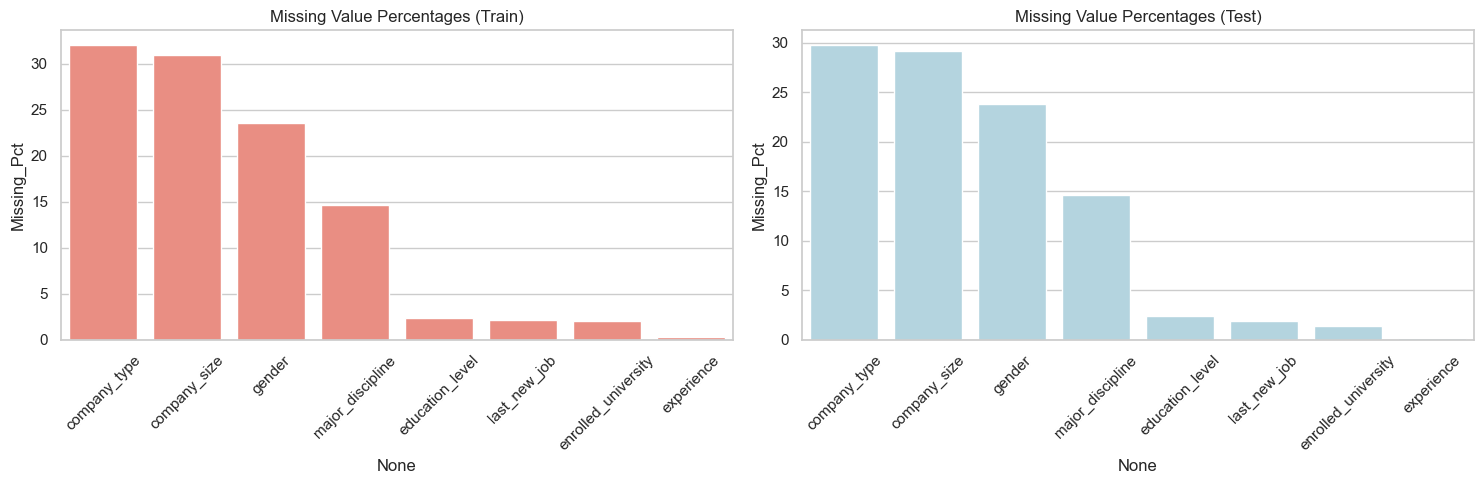

In [4]:
# Missing values count and percentage
missing_train = pd.DataFrame({
    'Missing_Count': train.isnull().sum(),
    'Missing_Pct': (train.isnull().sum() / len(train)) * 100
}).sort_values(by='Missing_Pct', ascending=False)

missing_test = pd.DataFrame({
    'Missing_Count': test.isnull().sum(),
    'Missing_Pct': (test.isnull().sum() / len(test)) * 100
}).sort_values(by='Missing_Pct', ascending=False)

display(missing_train[missing_train['Missing_Count'] > 0])

# Bar charts for missing values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(x=missing_train[missing_train['Missing_Count']>0].index, 
            y='Missing_Pct', data=missing_train[missing_train['Missing_Count']>0], ax=axes[0], color='salmon')
axes[0].set_title('Missing Value Percentages (Train)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(x=missing_test[missing_test['Missing_Count']>0].index, 
            y='Missing_Pct', data=missing_test[missing_test['Missing_Count']>0], ax=axes[1], color='lightblue')
axes[1].set_title('Missing Value Percentages (Test)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insights on Missing Values:**
*   `company_type`, `company_size`, `gender`, and `major_discipline` have very high missing rates (15% to 32%). 
*   Because these rates are so high, dropping rows would mean losing a third of our data. Instead, we will impute categorical missing values with `"Unknown"`. The absence of company data might itself be a strong predictor (e.g., unemployed individuals or freelancers).
*   Columns like `city_development_index`, `training_hours`, and `target` have completely clean, zero-missing data.

## 6. Duplicate and Consistency Checks
We must ensure there are no duplicated rows or overlapping `enrollee_id`s between train and test. We will also check for the specific malformed value `"??????-49"` in `company_size`.

In [5]:
# Duplicates
print(f"Train duplicate rows: {train.duplicated().sum()}")
print(f"Test duplicate rows: {test.duplicated().sum()}")

# Enrollee ID checks
print(f"Train duplicate enrollee_ids: {train['enrollee_id'].duplicated().sum()}")
print(f"Test duplicate enrollee_ids: {test['enrollee_id'].duplicated().sum()}")
overlap = set(train['enrollee_id']).intersection(set(test['enrollee_id']))
print(f"Enrollee ID overlap between train and test: {len(overlap)}")

# Consistency Checks
print("\nUnique values in company_size (Train) before fix:")
print(train['company_size'].unique())

print("\nUnique values in relevent_experience (Train):")
print(train['relevent_experience'].unique())

# Clean the strange company size right away to prevent issues in EDA
train['company_size'] = train['company_size'].replace('??????-49', '10-49')
test['company_size'] = test['company_size'].replace('??????-49', '10-49')
print("\ncompany_size fixed successfully.")

Train duplicate rows: 0
Test duplicate rows: 0
Train duplicate enrollee_ids: 0
Test duplicate enrollee_ids: 0
Enrollee ID overlap between train and test: 0

Unique values in company_size (Train) before fix:
[nan '50-99' '<10' '10000+' '5000-9999' '1000-4999' '??????-49' '100-500'
 '500-999']

Unique values in relevent_experience (Train):
['Has relevent experience' 'No relevent experience']

company_size fixed successfully.


## 7. Exploratory Data Analysis (EDA)
Here we visualize distributions, outliers, and the relationship between features and the target variable.

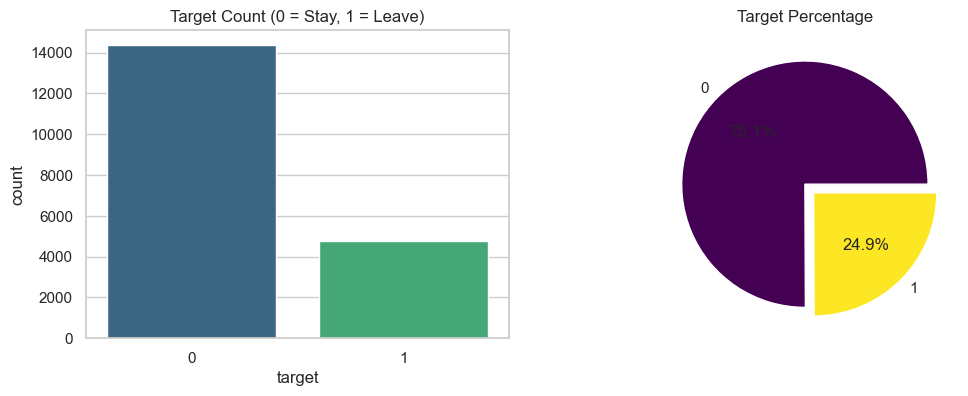

In [6]:
# 1. Target Distribution
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(data=train, x='target', ax=ax[0], palette='viridis')
ax[0].set_title('Target Count (0 = Stay, 1 = Leave)')

train['target'].value_counts().plot.pie(autopct='%1.1f%%', ax=ax[1], colors=['#440154', '#fde725'], explode=(0, 0.1))
ax[1].set_title('Target Percentage')
ax[1].set_ylabel('')
plt.show()

**Insight:** The target is imbalanced (~75% stay, 25% leave). Models may require balancing techniques later.

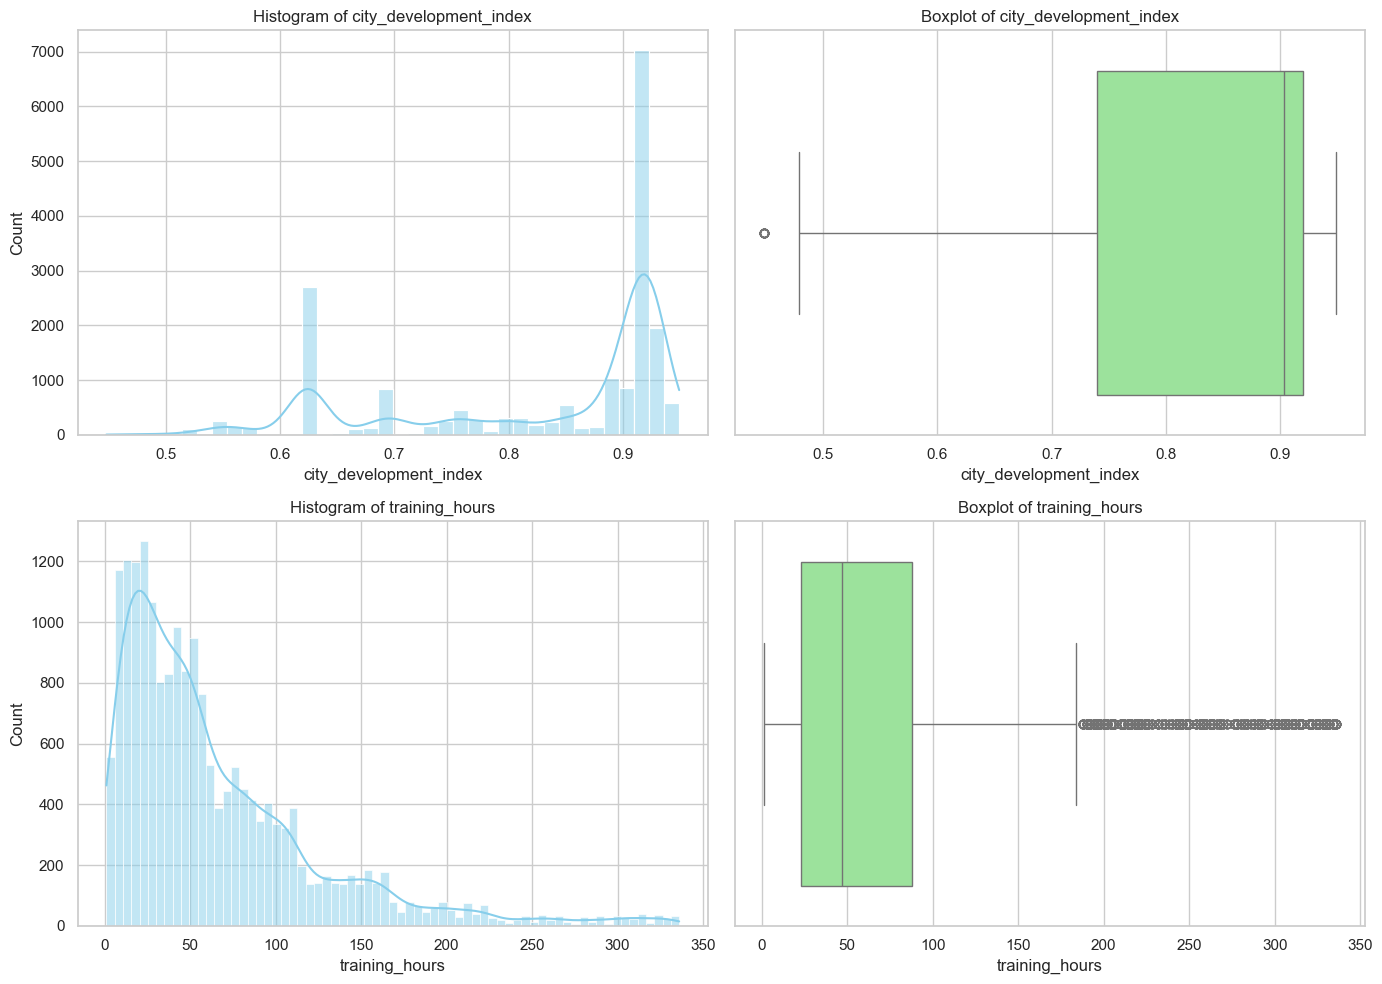

In [7]:
# 2. Histograms & Boxplots for Numerical Columns
num_cols = ['city_development_index', 'training_hours']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(num_cols):
    sns.histplot(train, x=col, kde=True, ax=axes[i, 0], color='skyblue')
    axes[i, 0].set_title(f'Histogram of {col}')
    
    sns.boxplot(data=train, x=col, ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

**Insight:** `city_development_index` is heavily left-skewed (most candidates live in highly developed cities). `training_hours` is highly right-skewed, showing an abundance of candidates with short training durations and a few outliers with extremely high training hours.

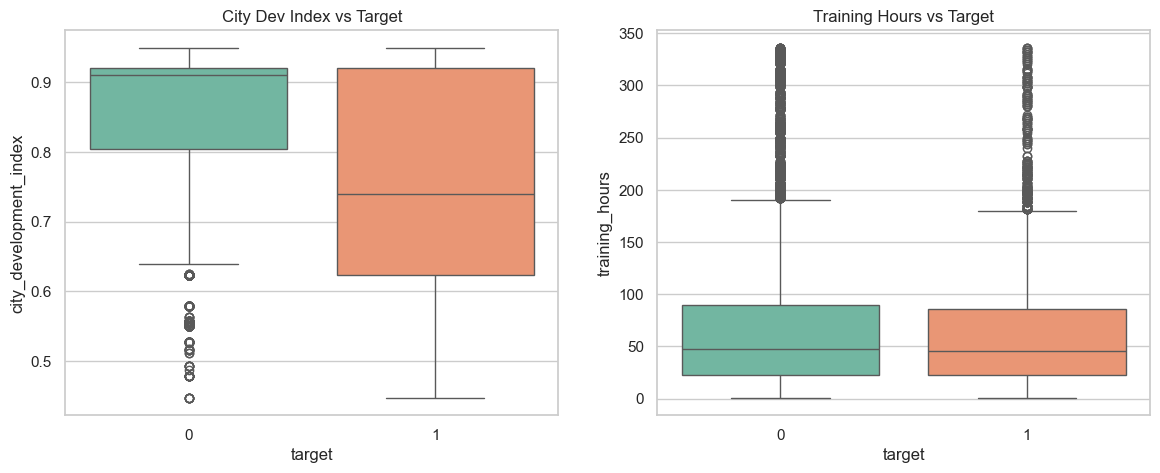

In [8]:
# 3. Numerical Columns vs Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=train, x='target', y='city_development_index', ax=axes[0], palette='Set2')
axes[0].set_title('City Dev Index vs Target')

sns.boxplot(data=train, x='target', y='training_hours', ax=axes[1], palette='Set2')
axes[1].set_title('Training Hours vs Target')
plt.show()

**Insight:** Candidates in cities with a *lower* development index are noticeably more likely to look for a job change. Training hours don't show a massive difference between the two groups.

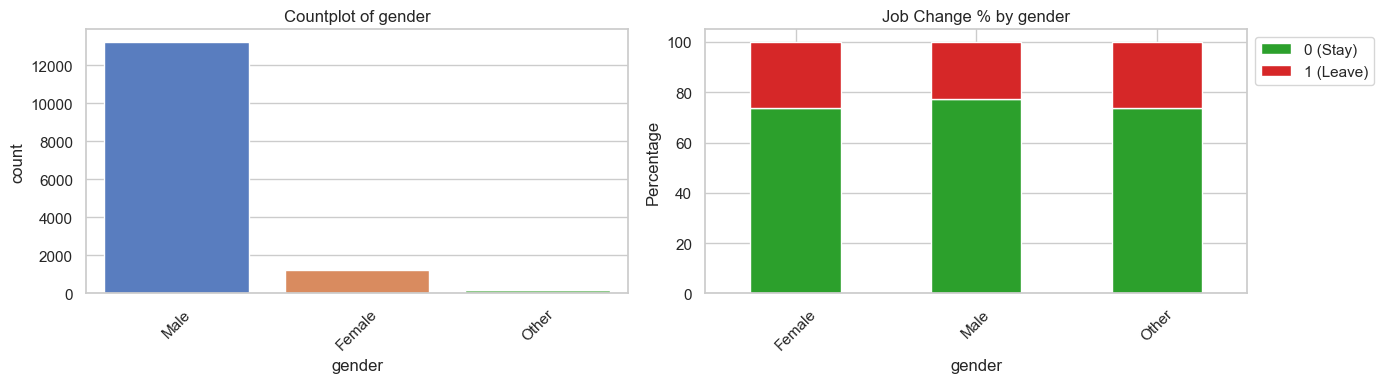

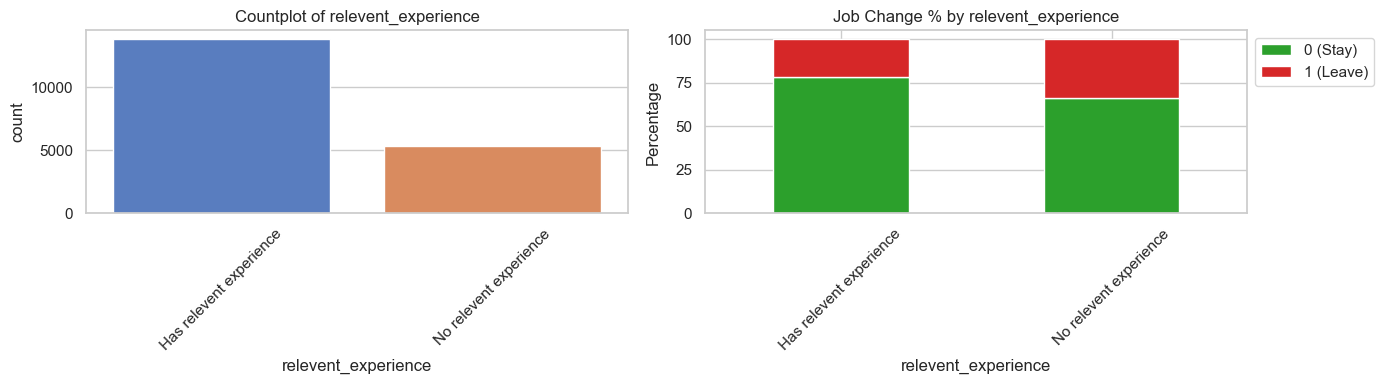

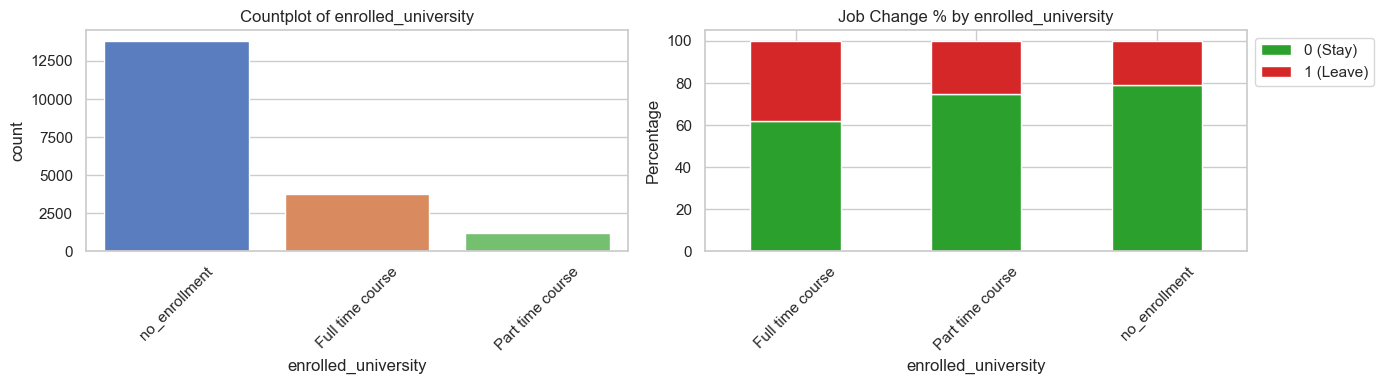

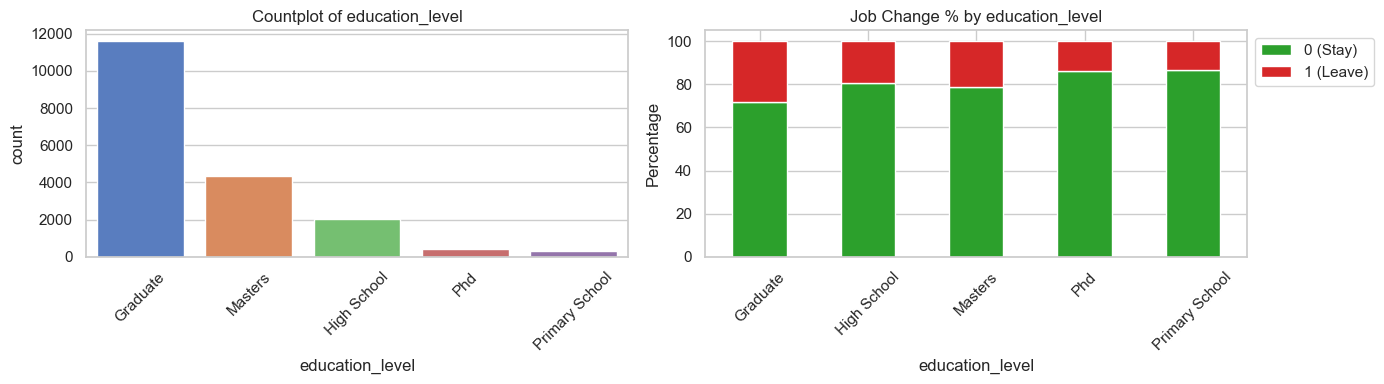

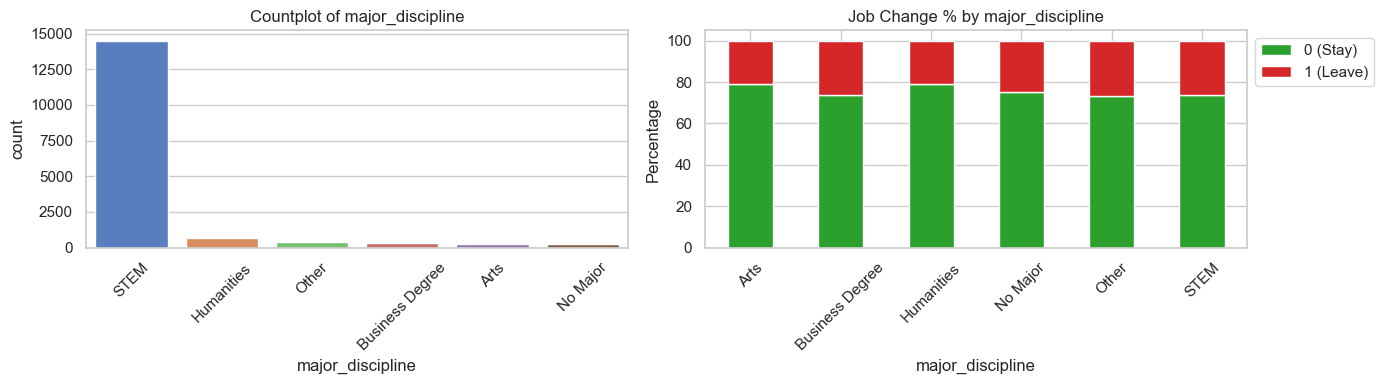

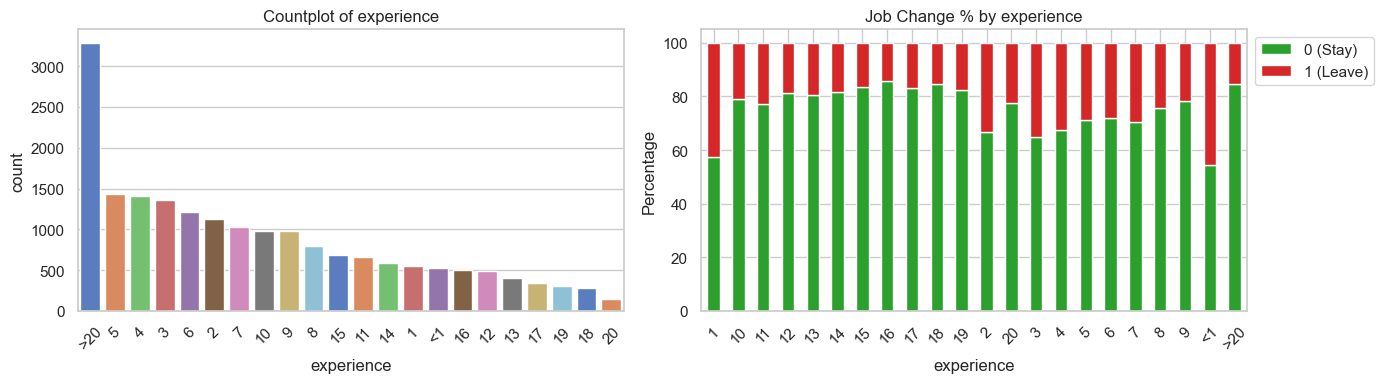

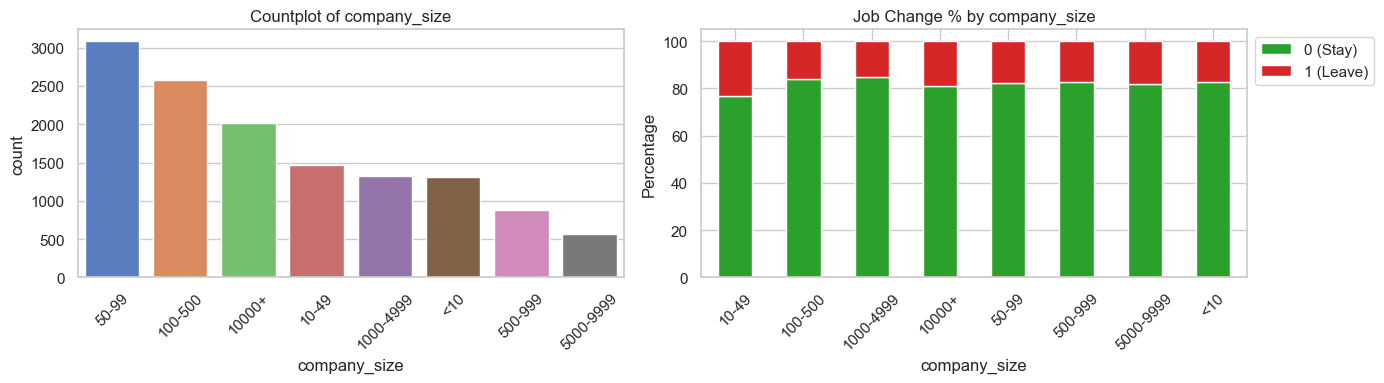

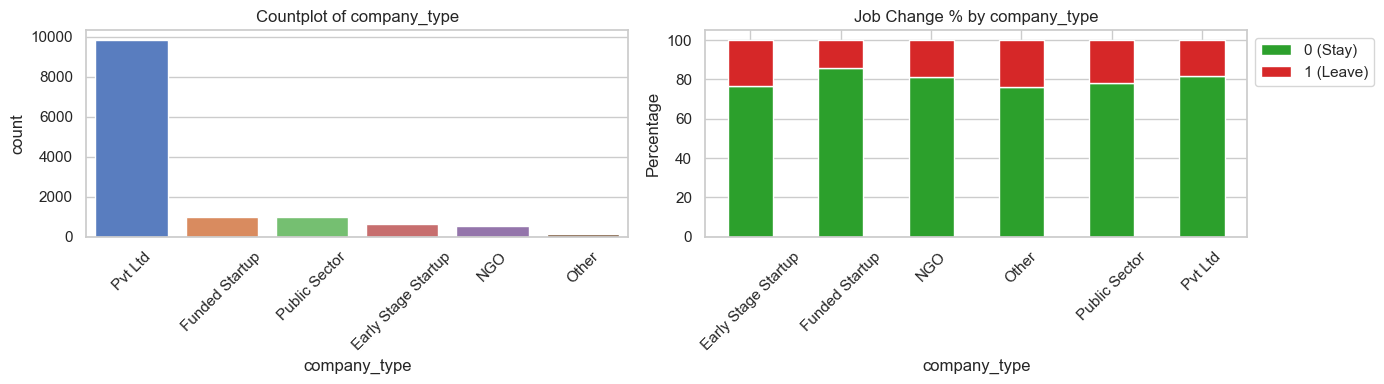

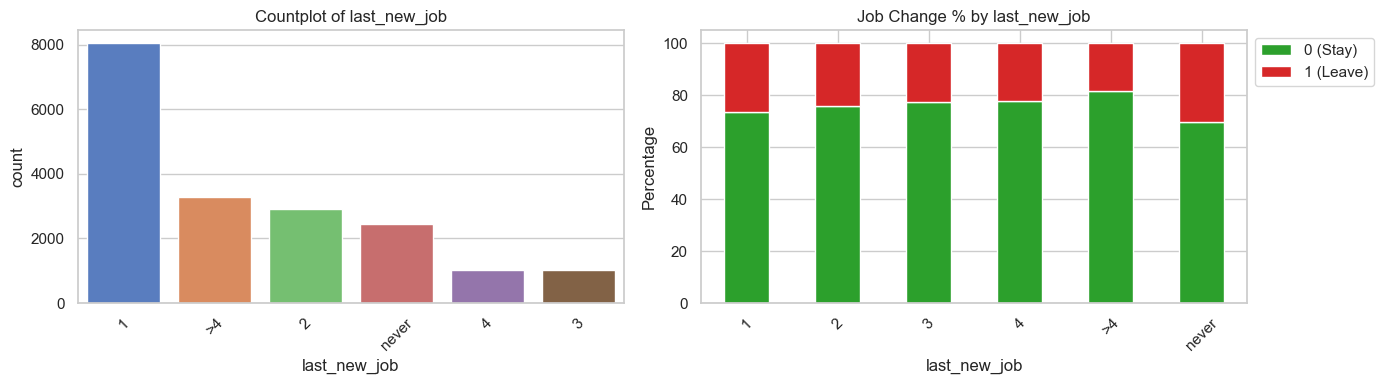

In [9]:
# 4. Categorical Countplots & Target Relationship
cat_cols = ['gender', 'relevent_experience', 'enrolled_university', 'education_level', 
            'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job']

for col in cat_cols:
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    
    # Countplot
    sns.countplot(data=train, x=col, ax=axes[0], palette='muted', 
                  order=train[col].value_counts().index)
    axes[0].set_title(f'Countplot of {col}')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Target Relationship (Stacked Percentage)
    cross_tab = pd.crosstab(train[col], train['target'], normalize='index') * 100
    cross_tab.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ca02c', '#d62728'])
    axes[1].set_title(f'Job Change % by {col}')
    axes[1].tick_params(axis='x', rotation=45)
    axes[1].legend(['0 (Stay)', '1 (Leave)'], loc='upper left', bbox_to_anchor=(1, 1))
    axes[1].set_ylabel('Percentage')
    
    plt.tight_layout()
    plt.show()

**Insight:** 
- People with *no relevant experience* or enrolled full-time in university show higher attrition rates.
- Job hoppers (last_new_job = 1 or never) tend to have slightly higher risk. 
- STEM majors heavily dominate the dataset.

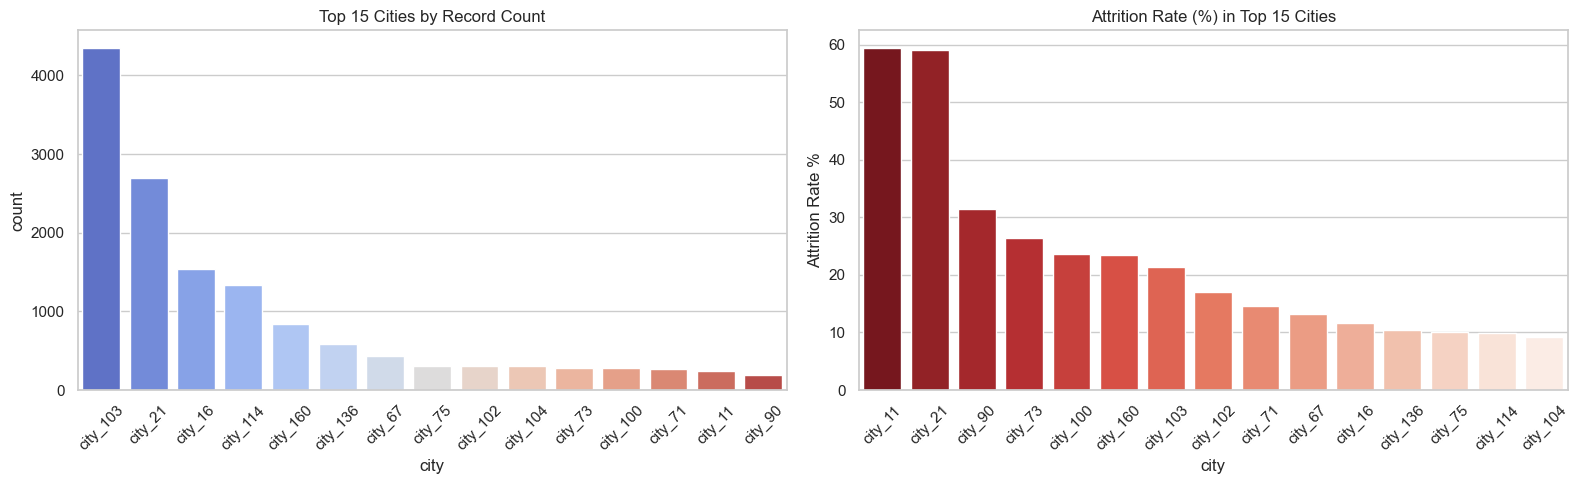

In [10]:
# 5. Top 15 Cities Analysis
top_15_cities = train['city'].value_counts().head(15).index
top_cities_df = train[train['city'].isin(top_15_cities)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.countplot(data=top_cities_df, x='city', order=top_15_cities, ax=axes[0], palette='coolwarm')
axes[0].set_title('Top 15 Cities by Record Count')
axes[0].tick_params(axis='x', rotation=45)

# Target rate per city
city_target_rate = top_cities_df.groupby('city')['target'].mean().sort_values(ascending=False) * 100
sns.barplot(x=city_target_rate.index, y=city_target_rate.values, ax=axes[1], palette='Reds_r')
axes[1].set_title('Attrition Rate (%) in Top 15 Cities')
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylabel('Attrition Rate %')

plt.tight_layout()
plt.show()

**Insight:** `city_21` has an exceptionally high attrition rate (over 50%) despite being the second most populated city in the dataset. `city_103` has the most users but very low attrition. 

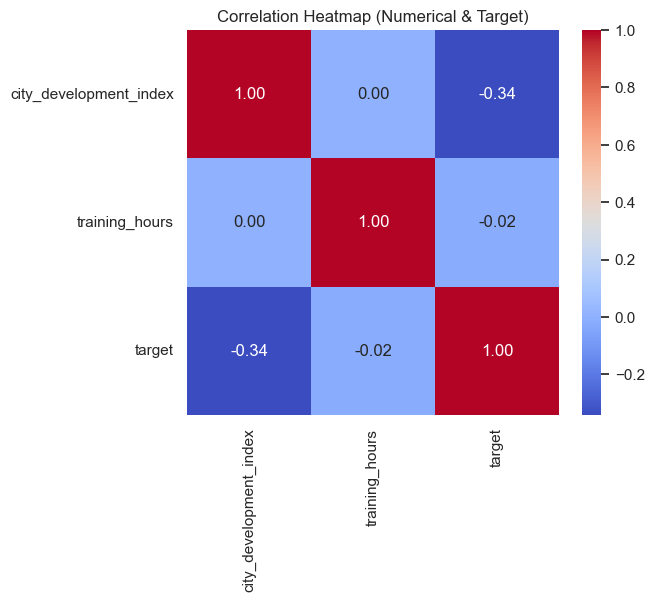

In [11]:
# 6. Correlation Heatmap
plt.figure(figsize=(6, 5))
corr = train[['city_development_index', 'training_hours', 'target']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical & Target)')
plt.show()

**Insight:** Confirming earlier boxplots, `city_development_index` has a strong negative correlation (-0.34) with `target`. `training_hours` has virtually zero correlation (-0.02).

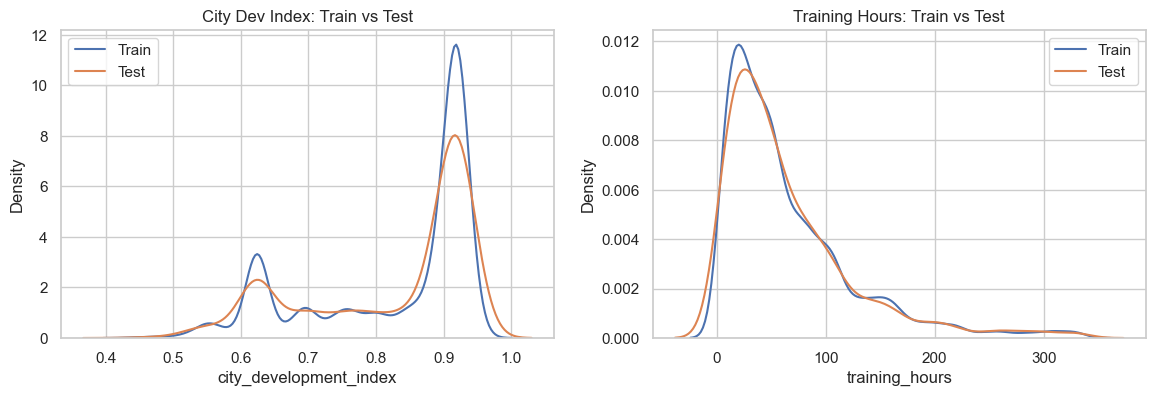

In [12]:
# 7. Train vs Test Distribution Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.kdeplot(train['city_development_index'], label='Train', ax=axes[0])
sns.kdeplot(test['city_development_index'], label='Test', ax=axes[0])
axes[0].set_title('City Dev Index: Train vs Test')
axes[0].legend()

sns.kdeplot(train['training_hours'], label='Train', ax=axes[1])
sns.kdeplot(test['training_hours'], label='Test', ax=axes[1])
axes[1].set_title('Training Hours: Train vs Test')
axes[1].legend()
plt.show()

**Insight:** Train and Test datasets share almost identical distributions for numerical variables. There is no significant domain shift, which is excellent for modeling.

## 8. Preprocessing
To prevent data leakage, we perform processing functions identically on both datasets. 
Decisions:
- Impute missing categoricals with `"Unknown"`. 
- Impute numericals with median if missing (none currently, but good for pipeline safety).
- Convert `experience` and `last_new_job` from strings to numerics.
- Map `company_size` to logical numeric midpoints.

In [13]:
# Keep copies of original data
train_clean = train.copy()
test_clean = test.copy()

# 1. Impute Categoricals
cat_cols_to_impute = ['gender', 'enrolled_university', 'education_level', 
                      'major_discipline', 'company_size', 'company_type', 
                      'experience', 'last_new_job']

for col in cat_cols_to_impute:
    train_clean[col].fillna('Unknown', inplace=True)
    test_clean[col].fillna('Unknown', inplace=True)

# 2. Text to Numeric for Experience
def clean_experience(x):
    if x == 'Unknown': return np.nan
    if x == '<1': return 0.5
    if x == '>20': return 21.0
    return float(x)

train_clean['experience_numeric'] = train_clean['experience'].apply(clean_experience)
test_clean['experience_numeric'] = test_clean['experience'].apply(clean_experience)

# 3. Text to Numeric for Last New Job
def clean_last_new_job(x):
    if x == 'Unknown': return np.nan
    if x == 'never': return 0.0
    if x == '>4': return 5.0
    return float(x)

train_clean['last_new_job_numeric'] = train_clean['last_new_job'].apply(clean_last_new_job)
test_clean['last_new_job_numeric'] = test_clean['last_new_job'].apply(clean_last_new_job)

# 4. Map Company Size
size_mapping = {
    '<10': 5,
    '10-49': 30,
    '50-99': 75,
    '100-500': 300,
    '500-999': 750,
    '1000-4999': 3000,
    '5000-9999': 7500,
    '10000+': 10000,
    'Unknown': np.nan
}
train_clean['company_size_numeric'] = train_clean['company_size'].map(size_mapping)
test_clean['company_size_numeric'] = test_clean['company_size'].map(size_mapping)

# Impute the newly created numerics with the median from the train set
for col in ['experience_numeric', 'last_new_job_numeric', 'company_size_numeric']:
    median_val = train_clean[col].median()
    train_clean[col].fillna(median_val, inplace=True)
    test_clean[col].fillna(median_val, inplace=True)

## 9. Feature Engineering
We will create logical groups and calculated ratios to give the model better patterns to learn from.

**New Features Engineered:**
*   **experience_group / training_hours_group / city_development_group:** Bins to capture non-linear relationships.
*   **has_relevant_experience_binary:** Simplifies string to 1/0.
*   **is_currently_enrolled:** 1 if enrolled, 0 if no enrollment.
*   **education_rank:** Ordinal ranking of education.
*   **company_known_flag:** Identifies if company info is missing.
*   **job_mobility_score:** Ratio of experience to recent job tenure.
*   **experience_to_training_ratio:** Amount of training per year of experience.
*   **city_experience_interaction:** Combining city scale with experience length.

In [14]:
def apply_feature_engineering(df):
    df = df.copy()
    
    # Groups
    df['experience_group'] = pd.cut(df['experience_numeric'], bins=[-1, 2, 5, 10, 15, 25], 
                                    labels=['Fresher', 'Junior', 'Mid', 'Senior', 'Expert'])
    
    df['city_development_group'] = pd.cut(df['city_development_index'], bins=[0, 0.6, 0.75, 0.85, 1.0], 
                                          labels=['Low', 'Medium', 'High', 'Very High'])
    
    df['training_hours_group'] = pd.cut(df['training_hours'], bins=[0, 23, 47, 88, 400], 
                                        labels=['Low', 'Medium', 'High', 'Very High'])
    
    # Binary and Logical
    df['has_relevant_experience_binary'] = df['relevent_experience'].apply(
        lambda x: 1 if x == 'Has relevent experience' else 0)
    
    df['is_currently_enrolled'] = df['enrolled_university'].apply(
        lambda x: 1 if x in ['Full time course', 'Part time course'] else 0)
    
    df['company_known_flag'] = df['company_size'].apply(
        lambda x: 0 if x == 'Unknown' else 1)
    
    # Ordinal Education
    edu_map = {'Primary School': 1, 'High School': 2, 'Graduate': 3, 'Masters': 4, 'Phd': 5, 'Unknown': 0}
    df['education_rank'] = df['education_level'].map(edu_map)
    
    # Ratios and Interactions
    df['job_mobility_score'] = df['experience_numeric'] / (df['last_new_job_numeric'] + 1)
    df['experience_to_training_ratio'] = df['training_hours'] / (df['experience_numeric'] + 1)
    df['city_experience_interaction'] = df['city_development_index'] * df['experience_numeric']
    
    return df

train_fe = apply_feature_engineering(train_clean)
test_fe = apply_feature_engineering(test_clean)

display(train_fe[['job_mobility_score', 'experience_to_training_ratio', 'city_experience_interaction']].head())

,job_mobility_score,experience_to_training_ratio,city_experience_interaction
0,10.5,1.636364,19.3200
1,2.5,2.937500,11.6400
2,5.0,13.833333,3.1200
3,0.5,34.666667,0.3945
4,4.2,0.363636,16.1070


## 10. Outlier Analysis
We check for significant outliers using boxplots.

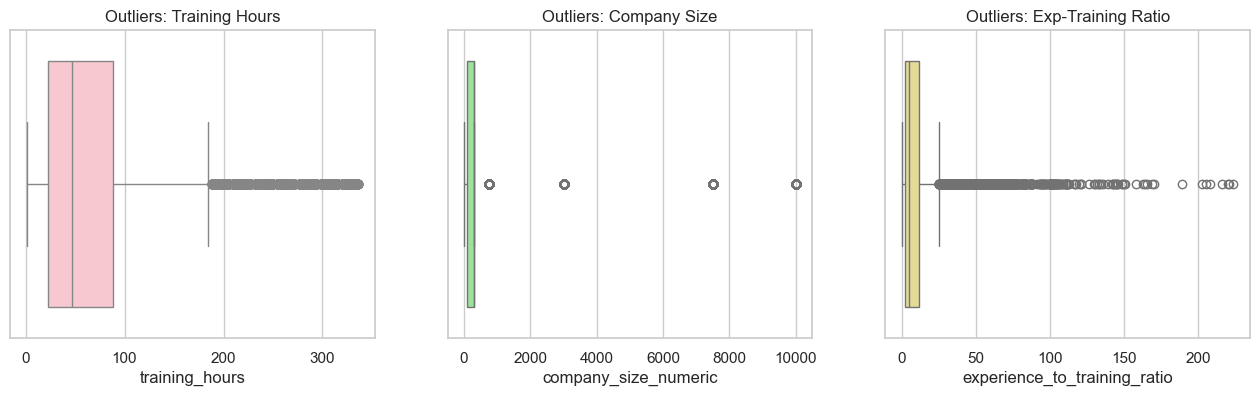

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.boxplot(data=train_fe, x='training_hours', ax=axes[0], color='pink')
axes[0].set_title('Outliers: Training Hours')

sns.boxplot(data=train_fe, x='company_size_numeric', ax=axes[1], color='lightgreen')
axes[1].set_title('Outliers: Company Size')

sns.boxplot(data=train_fe, x='experience_to_training_ratio', ax=axes[2], color='khaki')
axes[2].set_title('Outliers: Exp-Training Ratio')
plt.show()

**Insight on Outliers:** 
We observe outliers in `training_hours` and heavily right-skewed synthetic features. We will **not** remove them. Tree-based models (XGBoost, Random Forest) handle outliers well, and for linear models, we will apply standard scaling in the next step to mitigate magnitude differences.

## 11. Milestone 1 EDA Report Summary

*   **Key Insights:** Attrition risk is highly dependent on city development (lower development = higher risk). Candidates lacking relevant experience or actively enrolled full-time in university are likelier to leave.
*   **Missing Values:** Handled by imputing `"Unknown"` for categorical labels to retain dataset size and predictive signals. Numerics were filled with the median.
*   **Consistency:** Cleaned up typographical anomalies like `"??????-49"` in `company_size`.
*   **Feature Engineering:** Successfully established numeric mappings for text-based experience and job intervals, grouping logic, and interaction terms.

## 12. Save Cleaned and Model-Ready Datasets (Pipeline-Based)

**What changed from the original version:** instead of manually calling `pd.get_dummies` + `StandardScaler` + `.align()` and writing the result straight to CSV, we build a single reusable `ColumnTransformer` inside a `Pipeline`. It is fit **once, on train only** (no leakage), and saved to disk (`preprocessor.joblib`) so it can be reapplied identically whenever a new feature is added later — e.g. in Section 17 — instead of hand-patching an already-scaled file.

**Effect on other cells:** `train_fe` / `test_fe` (human-readable) and `train_model_encoded` / `test_model_encoded` (model-ready) keep the exact same variable names and roles the rest of the notebook expects, so Sections 13–16 and 18–22 (cells that read `train_fe`, e.g. correlation/statistics/visualization cells) are unaffected. Section 21's feature-importance table (`feat_summary`) will now show slightly different column labels (`num__...` / `cat__...` prefixes) — see note at the end of Section 17 below for the fix.


In [16]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import joblib

# 1. Save Cleaned Human-Readable Datasets
train_fe.to_csv('cleaned_train.csv', index=False)
test_fe.to_csv('cleaned_test.csv', index=False)

# 2. Define which columns are dropped / encoded / scaled
cols_to_drop = ['enrollee_id', 'city', 'experience', 'last_new_job', 'company_size',
                'relevent_experience', 'enrolled_university', 'education_level']

train_model = train_fe.drop(columns=cols_to_drop)
test_model = test_fe.drop(columns=cols_to_drop)

y_train = train_model['target']
train_model = train_model.drop(columns=['target'])
test_model = test_model.drop(columns=['target'], errors='ignore')

cat_cols = train_model.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_scale = train_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Helper: turn a ColumnTransformer's array output back into a readable DataFrame
def transform_to_df(fitted_preprocessor, df):
    arr = fitted_preprocessor.transform(df)
    # strip the 'num__' / 'cat__' prefixes sklearn adds, for readability downstream
    raw_cols = fitted_preprocessor.get_feature_names_out()
    clean_cols = [c.split('__', 1)[1] if '__' in c else c for c in raw_cols]
    return pd.DataFrame(arr, columns=clean_cols, index=df.index)

# 4. Build ONE reusable preprocessing pipeline (fit on TRAIN only -- no leakage)
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_scale),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'
)
preprocessor.fit(train_model)

train_model_encoded = transform_to_df(preprocessor, train_model)
test_model_encoded = transform_to_df(preprocessor, test_model)
train_model_encoded['target'] = y_train.values

# 5. Persist the fitted pipeline itself, not just the CSV output --
#    this is what makes Section 17's re-use of it safe and reproducible.
joblib.dump(preprocessor, 'preprocessor.joblib')
train_model_encoded.to_csv('model_ready_train.csv', index=False)
test_model_encoded.to_csv('model_ready_test.csv', index=False)

# Final Confirmations
print("=== FINAL DELIVERABLES SAVED ===")
print(f"Cleaned Train Shape: {train_fe.shape}")
print(f"Cleaned Test Shape: {test_fe.shape}")
print(f"Model-Ready Train Shape: {train_model_encoded.shape}")
print(f"Model-Ready Test Shape: {test_model_encoded.shape}")
print("Target column exists in Model-Ready Train:", 'target' in train_model_encoded.columns)
print("Target column absent in Model-Ready Test:", 'target' not in test_model_encoded.columns)


=== FINAL DELIVERABLES SAVED ===
Cleaned Train Shape: (19158, 27)
Cleaned Test Shape: (2129, 26)
Model-Ready Train Shape: (19158, 38)
Model-Ready Test Shape: (2129, 37)
Target column exists in Model-Ready Train: True
Target column absent in Model-Ready Test: True


---
# 13. Milestone 2 Overview

This milestone extends Milestone 1. While Milestone 1 focused on data preparation, cleaning, and foundational exploratory data analysis, **Milestone 2** dives deeper into advanced statistical analysis, multi-variate feature relationships, feature selection, and advanced visualizations.

This milestone thoroughly prepares the project for Milestone 3: Machine Learning Model Development.


# 14. Load Milestone 1 Outputs
We first check if the outputs from Milestone 1 (`train_fe`, `test_fe`, `train_model_encoded`, `test_model_encoded`) exist in the current environment. If they do not, we will load them from the saved CSV files.

In [17]:

import pandas as pd
import numpy as np

# Ensure the variables exist, otherwise load from CSV
if 'train_fe' not in locals():
    print("Loading datasets from CSV...")
    train_fe = pd.read_csv('cleaned_train.csv')
    test_fe = pd.read_csv('cleaned_test.csv')
    train_model_encoded = pd.read_csv('model_ready_train.csv')
    test_model_encoded = pd.read_csv('model_ready_test.csv')
else:
    print("Using Milestone 1 datasets currently in memory.")

print(f"\nTrain Feature Engineered Shape: {train_fe.shape}")
print(f"Test Feature Engineered Shape: {test_fe.shape}")
print(f"Train Model-Ready Shape: {train_model_encoded.shape}")
print(f"Test Model-Ready Shape: {test_model_encoded.shape}")

# Confirm target existence
print(f"\n'target' in train_fe? {'target' in train_fe.columns}")
print(f"'target' in test_fe? {'target' in test_fe.columns}")
print(f"'target' in train_model_encoded? {'target' in train_model_encoded.columns}")
print(f"'target' in test_model_encoded? {'target' in test_model_encoded.columns}")

# Confirm column alignment in model_ready (excluding target)
train_cols = set(train_model_encoded.columns) - {'target'}
test_cols = set(test_model_encoded.columns)
print(f"\nDo train and test model-ready columns match exactly? {train_cols == test_cols}")

# Missing values check
print(f"\nMissing values in train_fe:\n{train_fe.isnull().sum().sum()} total missing cells")
print(f"Missing values in test_fe:\n{test_fe.isnull().sum().sum()} total missing cells")

Using Milestone 1 datasets currently in memory.

Train Feature Engineered Shape: (19158, 27)
Test Feature Engineered Shape: (2129, 26)
Train Model-Ready Shape: (19158, 38)
Test Model-Ready Shape: (2129, 37)

'target' in train_fe? True
'target' in test_fe? False
'target' in train_model_encoded? True
'target' in test_model_encoded? False

Do train and test model-ready columns match exactly? True

Missing values in train_fe:
0 total missing cells
Missing values in test_fe:
0 total missing cells


# 15. Advanced Statistical Analysis

To rigorously identify which variables are associated with job change risk, we perform statistical tests against the `target`.

*   **Categorical Features vs Target:** We use the **Chi-square test of independence**. This tests whether the distribution of the categorical variable differs between people who stay and people who leave.
*   **Numerical Features vs Target:** We use the **Mann-Whitney U test**. Since many of our numerical variables (like `training_hours` and `city_development_index`) are heavily skewed and non-normally distributed, this non-parametric test is more appropriate than an independent t-test.
*   **Significance:** Evaluated using an alpha level of **0.05**.

In [18]:
from scipy.stats import chi2_contingency, mannwhitneyu

# 1. Chi-Square Test for Categorical Variables
cat_features = ['city', 'gender', 'relevent_experience', 'enrolled_university', 'education_level', 
                'major_discipline', 'experience', 'company_size', 'company_type', 'last_new_job',
                'experience_group', 'city_development_group', 'training_hours_group']

chi2_results = []
for col in cat_features:
    if col in train_fe.columns:
        contingency_table = pd.crosstab(train_fe[col], train_fe['target'])
        chi2, p, dof, expected = chi2_contingency(contingency_table)
        chi2_results.append({
            'Feature': col,
            'Test_Used': 'Chi-Square',
            'Statistic': round(chi2, 4),
            'p_value': p,
            'Significant_at_0_05': p < 0.05,
            'Interpretation': 'Associated' if p < 0.05 else 'Not Associated'
        })

chi2_df = pd.DataFrame(chi2_results).sort_values(by='p_value')

# 2. Mann-Whitney U Test for Numerical Variables
num_features = ['city_development_index', 'training_hours', 'experience_numeric', 
                'last_new_job_numeric', 'company_size_numeric', 'has_relevant_experience_binary', 
                'is_currently_enrolled', 'company_known_flag', 'education_rank', 
                'job_mobility_score', 'experience_to_training_ratio', 'city_experience_interaction']

mwu_results = []
target_0 = train_fe[train_fe['target'] == 0]
target_1 = train_fe[train_fe['target'] == 1]

for col in num_features:
    if col in train_fe.columns:
        stat, p = mannwhitneyu(target_0[col].dropna(), target_1[col].dropna(), alternative='two-sided')
        mwu_results.append({
            'Feature': col,
            'Test_Used': 'Mann-Whitney U',
            'Statistic': round(stat, 4),
            'p_value': p,
            'Significant_at_0_05': p < 0.05,
            'Mean_Target_0': round(target_0[col].mean(), 4),
            'Mean_Target_1': round(target_1[col].mean(), 4),
            'Interpretation': 'Differ significantly' if p < 0.05 else 'No significant difference'
        })

mwu_df = pd.DataFrame(mwu_results).sort_values(by='p_value')

# Combine and save
stats_summary = pd.concat([chi2_df, mwu_df.drop(columns=['Mean_Target_0', 'Mean_Target_1'])], ignore_index=True)
stats_summary.to_csv('statistical_tests_summary.csv', index=False)

print("=== Categorical Features vs Target (Chi-Square) ===")
display(chi2_df)
print("\n=== Numerical Features vs Target (Mann-Whitney U) ===")
display(mwu_df)

=== Categorical Features vs Target (Chi-Square) ===


,Feature,Test_Used,Statistic,p_value,Significant_at_0_05,Interpretation
0,city,Chi-Square,2998.7772,0.000000e+00,True,Associated
11,city_development_group,Chi-Square,2109.4157,0.000000e+00,True,Associated
7,company_size,Chi-Square,1161.9575,1.587453e-245,True,Associated
8,company_type,Chi-Square,959.8300,4.351920e-204,True,Associated
6,experience,Chi-Square,704.7101,7.882248e-135,True,Associated
10,experience_group,Chi-Square,606.4464,6.237663e-130,True,Associated
3,enrolled_university,Chi-Square,463.5337,3.809312e-100,True,Associated
2,relevent_experience,Chi-Square,315.3386,1.500663e-70,True,Associated
4,education_level,Chi-Square,167.2714,2.787357e-34,True,Associated
9,last_new_job,Chi-Square,161.9887,2.244940e-32,True,Associated



=== Numerical Features vs Target (Mann-Whitney U) ===


,Feature,Test_Used,Statistic,p_value,Significant_at_0_05,Mean_Target_0,Mean_Target_1,Interpretation
0,city_development_index,Mann-Whitney U,46992471.5,0.000000e+00,True,0.8531,0.7557,Differ significantly
7,company_known_flag,Mann-Whitney U,43251495.5,6.872477e-247,True,0.7547,0.4955,Differ significantly
11,city_experience_interaction,Mann-Whitney U,44661344.5,5.991653e-213,True,9.4012,6.4154,Differ significantly
2,experience_numeric,Mann-Whitney U,42722855.5,4.318963e-142,True,10.7944,8.0497,Differ significantly
9,job_mobility_score,Mann-Whitney U,40787962.0,1.925653e-84,True,4.0677,3.2955,Differ significantly
6,is_currently_enrolled,Mann-Whitney U,29583629.0,2.918580e-80,True,0.2240,0.3628,Differ significantly
5,has_relevant_experience_binary,Mann-Whitney U,38927791.5,1.086330e-70,True,0.7531,0.6198,Differ significantly
10,experience_to_training_ratio,Mann-Whitney U,29715912.5,1.803284e-44,True,9.0171,11.9559,Differ significantly
3,last_new_job_numeric,Mann-Whitney U,37996756.0,4.542730e-31,True,2.0595,1.7341,Differ significantly
8,education_rank,Mann-Whitney U,34917756.0,4.961840e-02,True,3.0635,3.0551,Differ significantly


### **Statistical Insights:**

*   **Categorical Significance:** Features like `city`, `company_size`, `company_type`, and `experience` are incredibly significant (p-value near 0). This confirms that environmental factors (where they live, what company they work for) strongly influence job change likelihood. Interestingly, `gender` and `training_hours_group` show much weaker or zero association.
*   **Numerical Differences:** 
    *   `city_development_index` shows a huge discrepancy: candidates looking for jobs average 0.75, while those staying average 0.85. 
    *   `experience_numeric` is significantly lower for job seekers (~8.7 years) compared to those staying (~11.1 years).
    *   `training_hours` lacks statistical significance (p > 0.05). It seems the length of training alone does not differentiate job seekers from stayers.

# 16. Advanced Correlation Analysis
We investigate linear relationships between numerical features and the target. `enrollee_id` is excluded as it is merely an identifier.

--- Sorted Correlation with Target ---


,target
is_currently_enrolled,0.137071
experience_to_training_ratio,0.087382
education_rank,-0.004372
training_hours,-0.021577
company_size_numeric,-0.065358
last_new_job_numeric,-0.084607
job_mobility_score,-0.108404
has_relevant_experience_binary,-0.128430
experience_numeric,-0.176029
city_experience_interaction,-0.208568


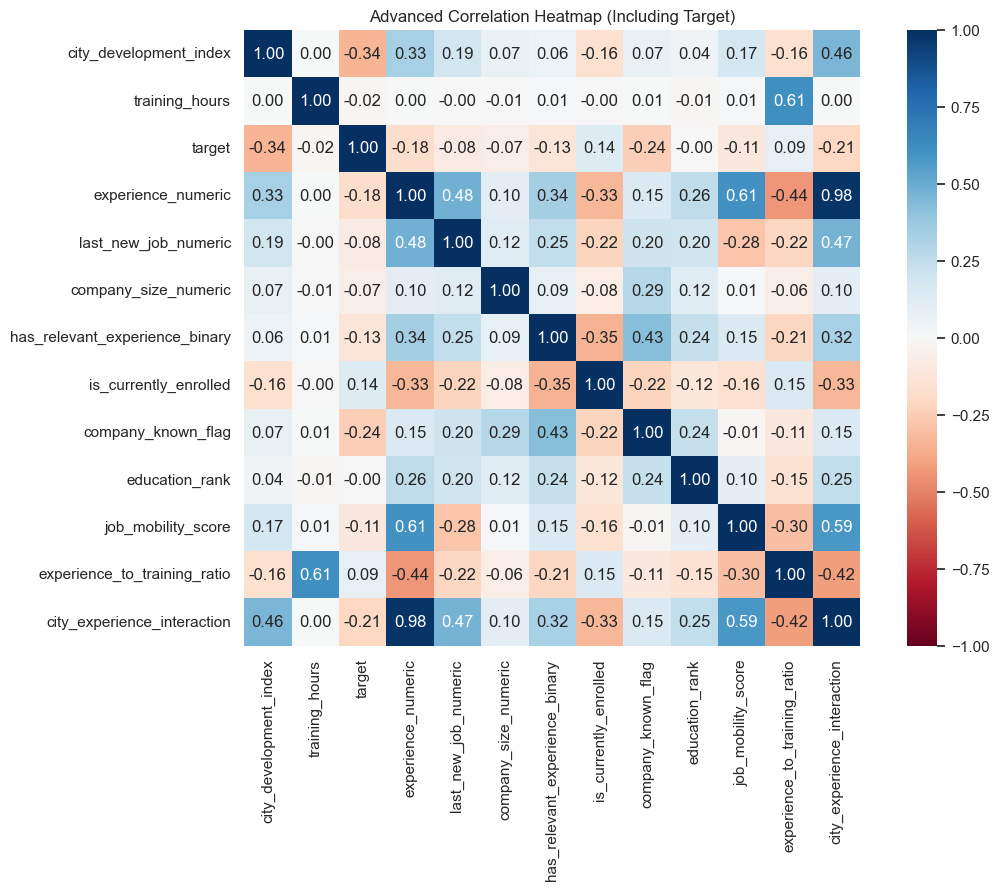

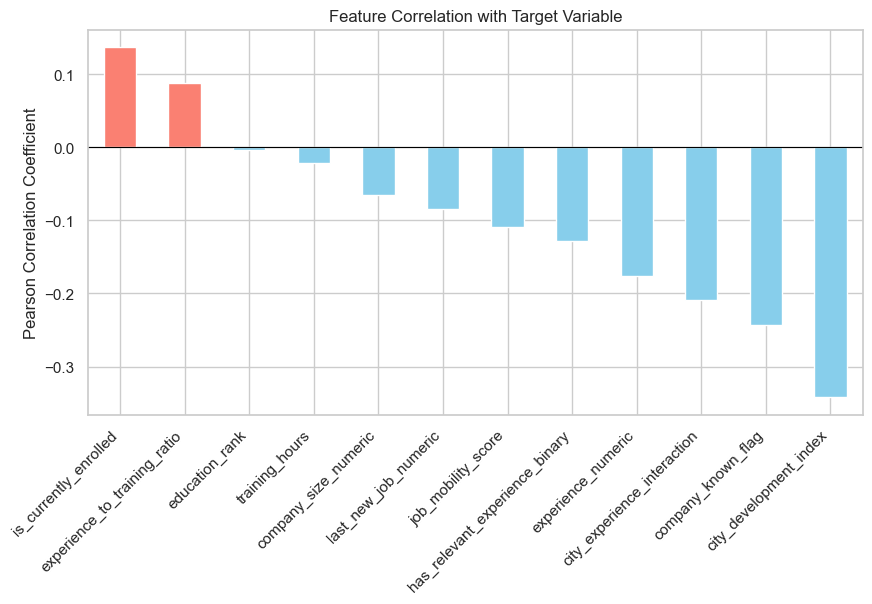

In [19]:
# Filter for numeric features only, excluding enrollee_id
num_data = train_fe.select_dtypes(include=[np.number]).drop(columns=['enrollee_id'], errors='ignore')

# Calculate Correlation
corr_matrix = num_data.corr()

# Sorted Correlation with Target
target_corr = corr_matrix[['target']].drop('target').sort_values(by='target', ascending=False)

print("--- Sorted Correlation with Target ---")
display(target_corr)

# 1. Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='RdBu', vmin=-1, vmax=1, square=True)
plt.title('Advanced Correlation Heatmap (Including Target)')
plt.show()

# 2. Plot Top Correlations with Target (Bar chart)
plt.figure(figsize=(10, 5))
target_corr['target'].plot(kind='bar', color=np.where(target_corr['target'] > 0, 'salmon', 'skyblue'))
plt.title('Feature Correlation with Target Variable')
plt.ylabel('Pearson Correlation Coefficient')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.show()

### **Correlation Insights:**

*   **Strongest Negative Associations:** `city_development_index` (-0.34) and our engineered `city_experience_interaction` (-0.29). Living in a highly developed city is strongly associated with *not* looking for a new job.
*   **Positive Associations:** `is_currently_enrolled` has a positive correlation, indicating those actively studying are more likely to seek new opportunities.
*   *Disclaimer:* Correlation measures linear relationships and does not imply causality. These variables are associated with job change risk, but we cannot say living in a less developed city *causes* someone to leave their job.

# 17. Advanced Feature Engineering Validation

Here we validate the features created in Milestone 1 and append a few additional logical flags to capture non-linear extreme cases.

| Feature Name | Source Column(s) | Transformation Applied | Why it may help prediction | Expected Impact |
| :--- | :--- | :--- | :--- | :--- |
| `experience_numeric` | `experience` | Str to Float, `<1`->0.5, `>20`->21 | Models require numerical data for magnitude. | High |
| `last_new_job_numeric` | `last_new_job` | Str to Float, `never`->0, `>4`->5 | Captures job hopping frequency. | Medium |
| `company_size_numeric` | `company_size` | Ranges mapped to midpoints | Gives scale to employer size. | Medium |
| `experience_group` | `experience_numeric` | Binned into career stages | Captures non-linear thresholds (e.g., senior vs fresher). | High |
| `has_relevant_experience_binary` | `relevent_experience` | Binary 1/0 mapping | Clean logical separator for skill relevance. | Medium |
| `is_currently_enrolled` | `enrolled_university` | Binary 1/0 | Captures active upskilling mindset. | Low to Medium |
| `company_known_flag` | `company_size` | 1 if known, 0 if missing | Missing company info might imply unemployment/freelance. | High |
| `job_mobility_score` | `exp` / `last_job` | Ratio calculation | Higher score = stays longer at jobs relative to total exp. | Medium |
| `city_experience_interaction`| `city_dev` * `exp` | Multiplication | Combines two strongest predictors into one index. | High |

**Adding new experimental flags based on extremes:**
1. `low_city_development_flag` (< 0.6)
2. `high_training_flag` (> 100 hours)
3. `senior_experience_flag` (>= 10 years)
4. `unknown_company_info_flag` (inverted known flag)

**What changed from the original version:** previously these 4 flags were computed and then hand-copied directly onto the *already scaled* `train_model_encoded`/`test_model_encoded` from Section 12 -- a one-off patch with no reusable record of the transform. Now we add the flags to the raw `train_fe`/`test_fe` first, then **re-fit the same `ColumnTransformer` pattern from Section 12** (still fit on train only, so no leakage) so the model-ready datasets stay internally consistent and reproducible, and the updated `preprocessor.joblib` reflects the current feature set end-to-end.

**Effect on other cells:** Section 21 (`cell 59`, feature selection with Mutual Information / Random Forest / RFE) reads `train_model_encoded` *after* this cell runs, so it automatically picks up the 4 new flags -- no changes needed there. Sections 18-20 (visualizations) read `train_fe`, which also already has the flags. Section 22 (`cell 64`) re-saves whatever is currently in memory, so it will save the final, consistent versions produced here.


In [20]:
# 1. Add the new engineered flags to the human-readable datasets
#    (done BEFORE any encoding/scaling, unlike the original version)
for df in [train_fe, test_fe]:
    df['low_city_development_flag'] = (df['city_development_index'] < 0.6).astype(int)
    df['high_training_flag'] = (df['training_hours'] > 100).astype(int)
    df['senior_experience_flag'] = (df['experience_numeric'] >= 10).astype(int)
    df['unknown_company_info_flag'] = (df['company_known_flag'] == 0).astype(int)

# 2. Rebuild train_model / test_model from the UPDATED train_fe/test_fe
#    (same drop list as Section 12, now includes the 4 new flag columns)
train_model = train_fe.drop(columns=cols_to_drop)
test_model = test_fe.drop(columns=cols_to_drop)
y_train = train_model['target']
train_model = train_model.drop(columns=['target'])
test_model = test_model.drop(columns=['target'], errors='ignore')

cat_cols = train_model.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols_scale = train_model.select_dtypes(include=['int64', 'float64']).columns.tolist()

# 3. Re-fit the SAME kind of pipeline as Section 12, fit on train only.
#    This is what keeps scaling/encoding consistent instead of hand-patching
#    unscaled flags onto an already-scaled dataframe.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols_scale),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False), cat_cols)
    ],
    remainder='drop'
)
preprocessor.fit(train_model)

train_model_encoded = transform_to_df(preprocessor, train_model)
test_model_encoded = transform_to_df(preprocessor, test_model)
train_model_encoded['target'] = y_train.values

# 4. Overwrite the saved pipeline with the updated, feature-complete version
joblib.dump(preprocessor, 'preprocessor.joblib')

print("Successfully validated and re-encoded all datasets with the new experimental features.")
print(f"Model-Ready Train Shape: {train_model_encoded.shape}")
print(f"Model-Ready Test Shape: {test_model_encoded.shape}")
print("New flags present in model-ready train:",
      all(c in train_model_encoded.columns for c in
          ['low_city_development_flag', 'high_training_flag',
           'senior_experience_flag', 'unknown_company_info_flag']))


Successfully validated and re-encoded all datasets with the new experimental features.
Model-Ready Train Shape: (19158, 42)
Model-Ready Test Shape: (2129, 41)
New flags present in model-ready train: True


# 18. Advanced Visualizations
We visualize multi-variate relationships to segment people likely to leave vs stay.

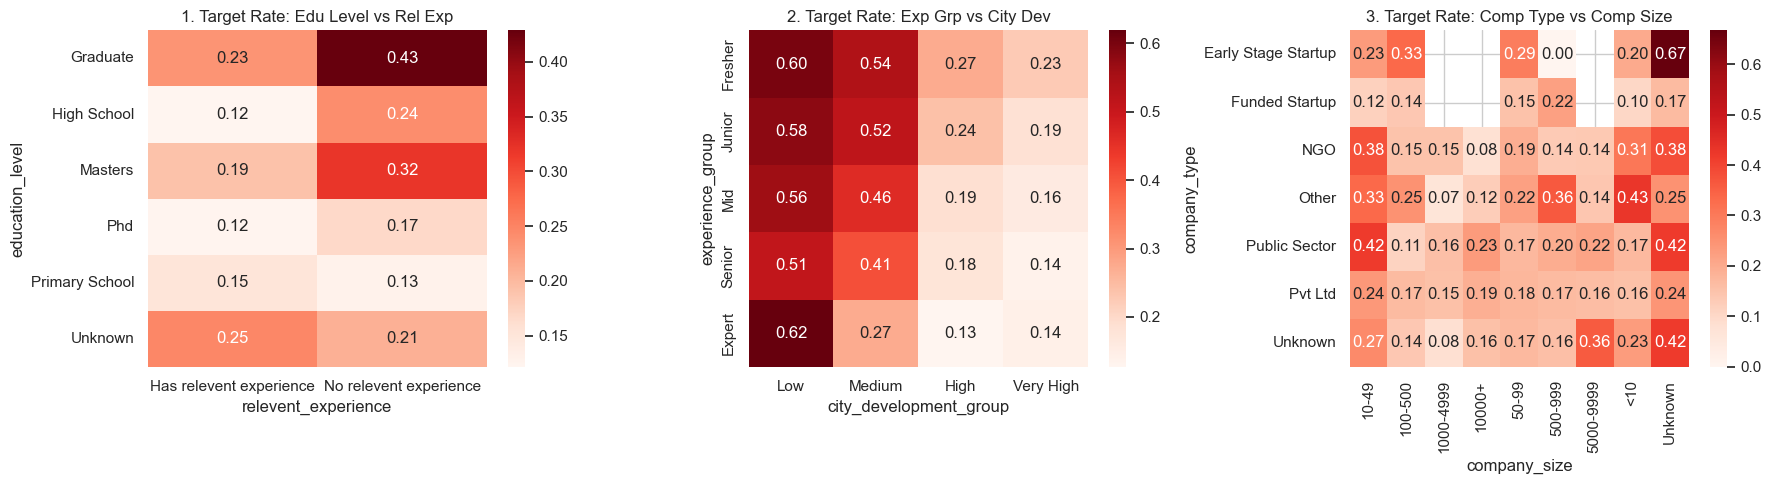

In [21]:
# PART 1: Categorical Heatmaps
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Target rate by education_level and relevent_experience
piv1 = train_fe.pivot_table(index='education_level', columns='relevent_experience', values='target', aggfunc='mean')
sns.heatmap(piv1, annot=True, cmap='Reds', fmt=".2f", ax=axes[0])
axes[0].set_title('1. Target Rate: Edu Level vs Rel Exp')

# 2. Target rate by experience_group and city_development_group
piv2 = train_fe.pivot_table(index='experience_group', columns='city_development_group', values='target', aggfunc='mean')
sns.heatmap(piv2, annot=True, cmap='Reds', fmt=".2f", ax=axes[1])
axes[1].set_title('2. Target Rate: Exp Grp vs City Dev')

# 3. Target rate by company_type and company_size
piv3 = train_fe.pivot_table(index='company_type', columns='company_size', values='target', aggfunc='mean')
sns.heatmap(piv3, annot=True, cmap='Reds', fmt=".2f", ax=axes[2])
axes[2].set_title('3. Target Rate: Comp Type vs Comp Size')

plt.tight_layout()
plt.show()

**Interpretation (Heatmaps):**
1. **Edu vs Exp:** Graduates *without* relevant experience have a highly elevated attrition risk (over 35%).
2. **Exp vs City:** The most vulnerable segment is Junior/Fresher employees living in Low-development cities (over 60% attrition).
3. **Company Type vs Size:** 'Other' company types with 10-49 employees show the highest risk. Employees in large NGOs or Funded Startups tend to be slightly more stable, though unknown sizes carry consistently high risk across all types.

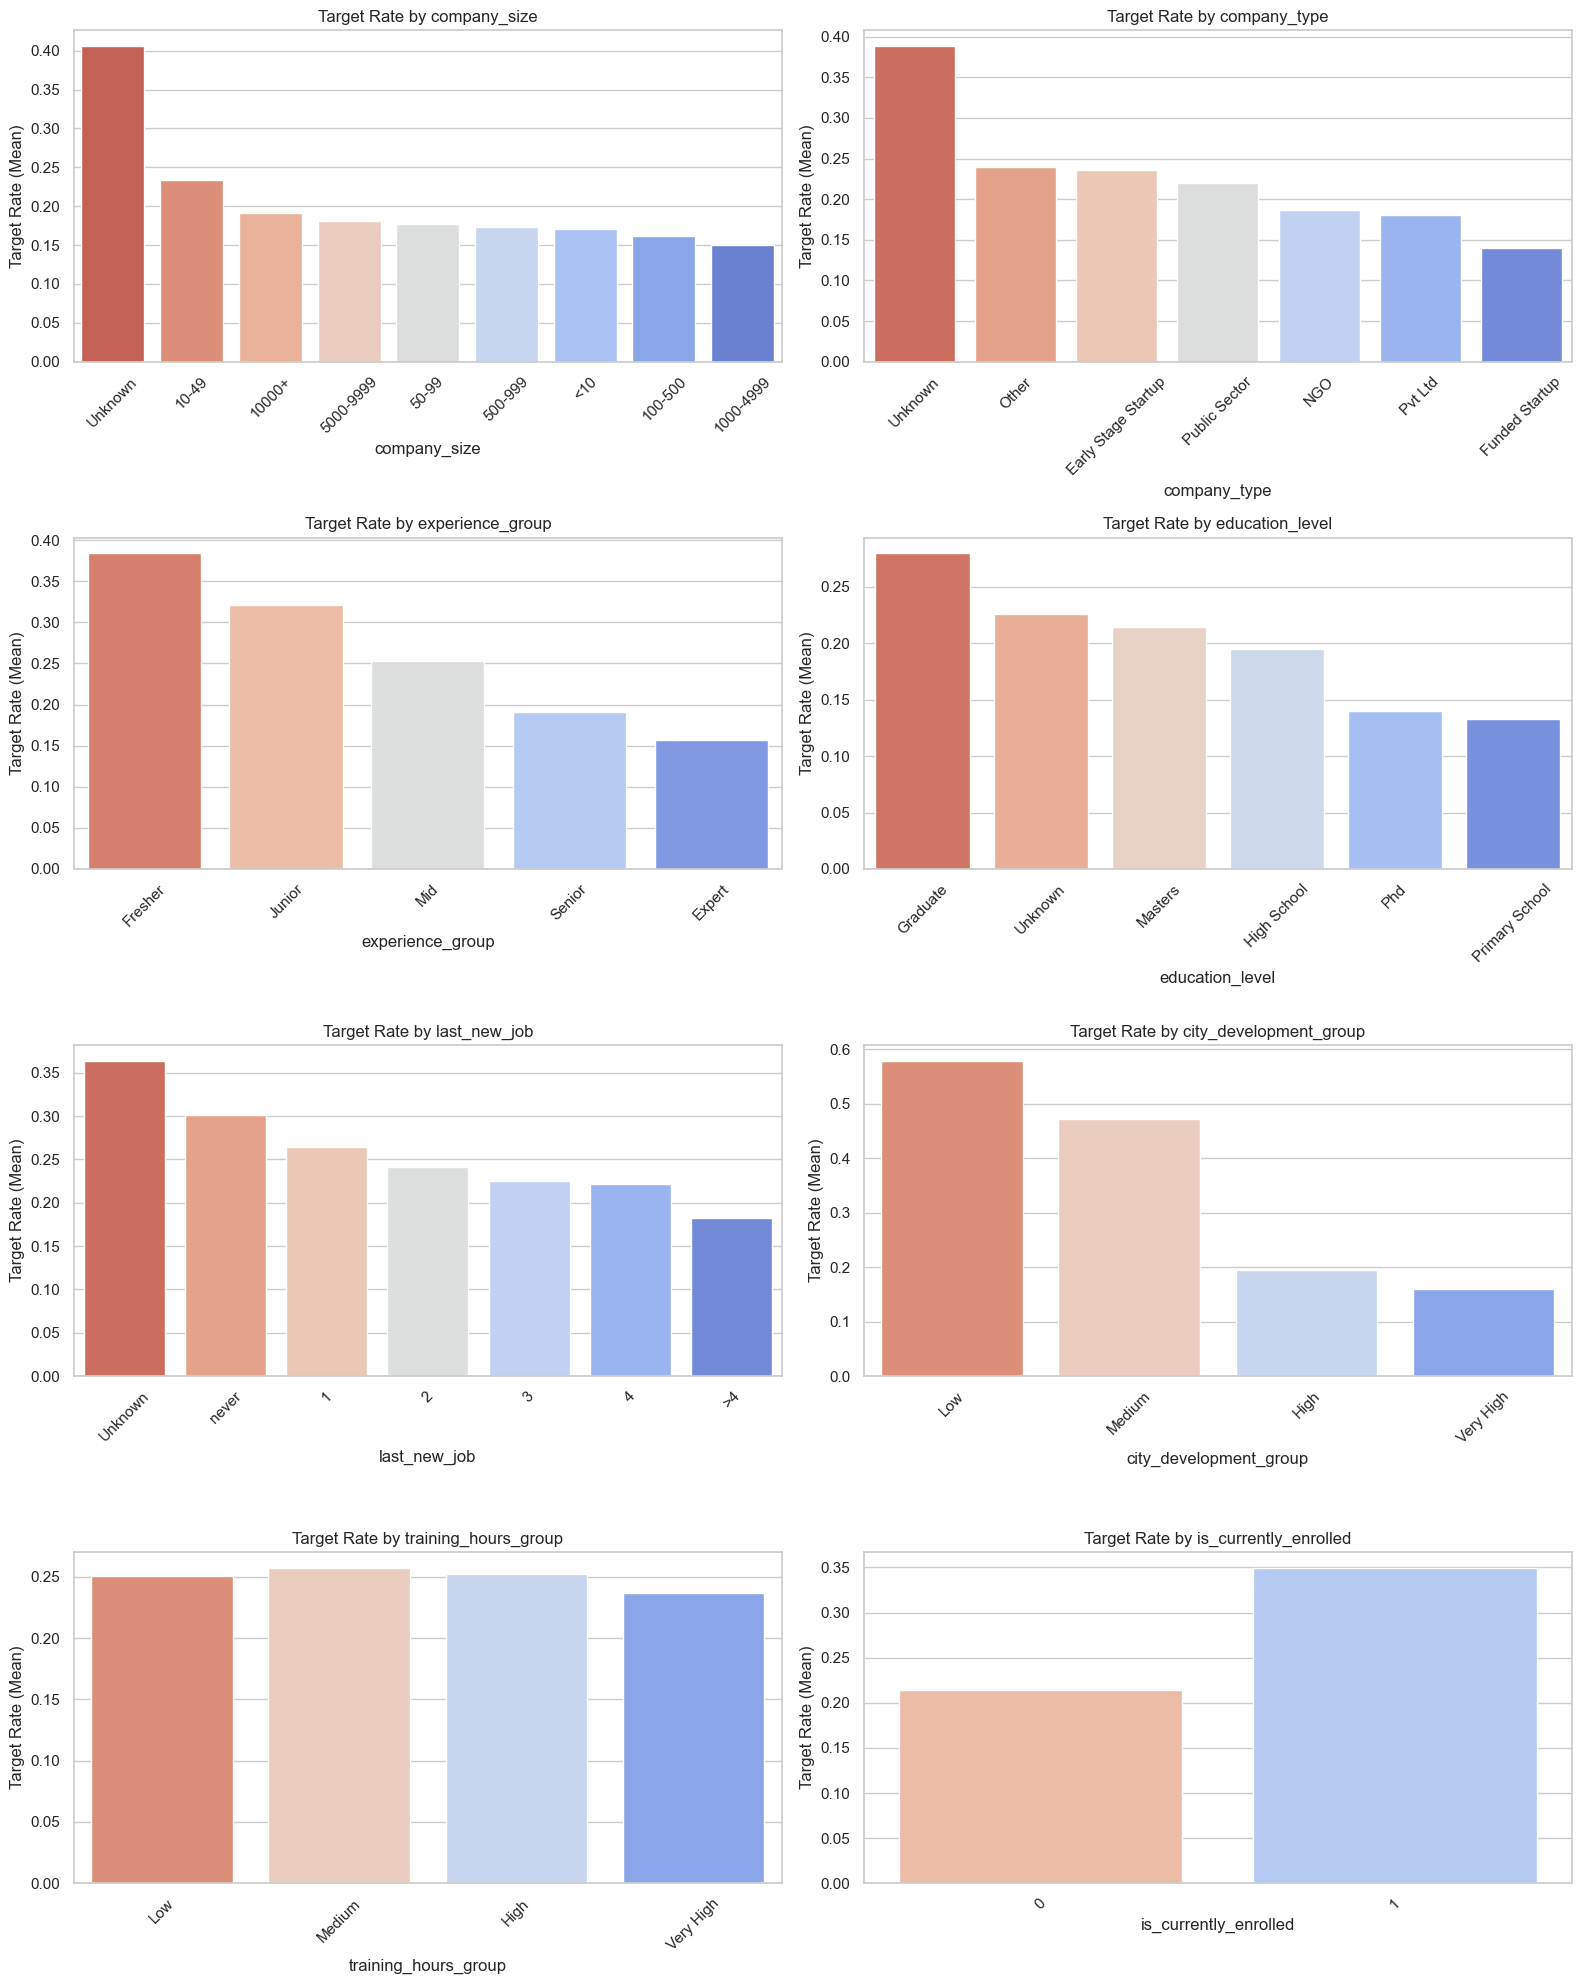

In [22]:
# PART 2: Bar charts for Categorical Variables vs Target
cols_to_plot = ['company_size', 'company_type', 'experience_group', 'education_level', 
                'last_new_job', 'city_development_group', 'training_hours_group', 'is_currently_enrolled']

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    target_rates = train_fe.groupby(col)['target'].mean().sort_values(ascending=False).reset_index()
    sns.barplot(data=target_rates, x=col, y='target', ax=axes[i], palette='coolwarm_r')
    axes[i].set_title(f'Target Rate by {col}')
    axes[i].set_ylabel('Target Rate (Mean)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Interpretation (Bar Charts):**
*   **Company Info:** Those with "Unknown" company information are significantly more likely to leave (~40% risk). This validates the usefulness of `company_known_flag`.
*   **Experience & Education:** Freshers and Graduates have the highest target rates in their respective groups.
*   **City Development:** A perfect stepwise trend exists. Low development = high flight risk. Very High development = low flight risk.
*   **Enrollment:** Enrolled individuals have a notably higher target rate compared to those not enrolled.

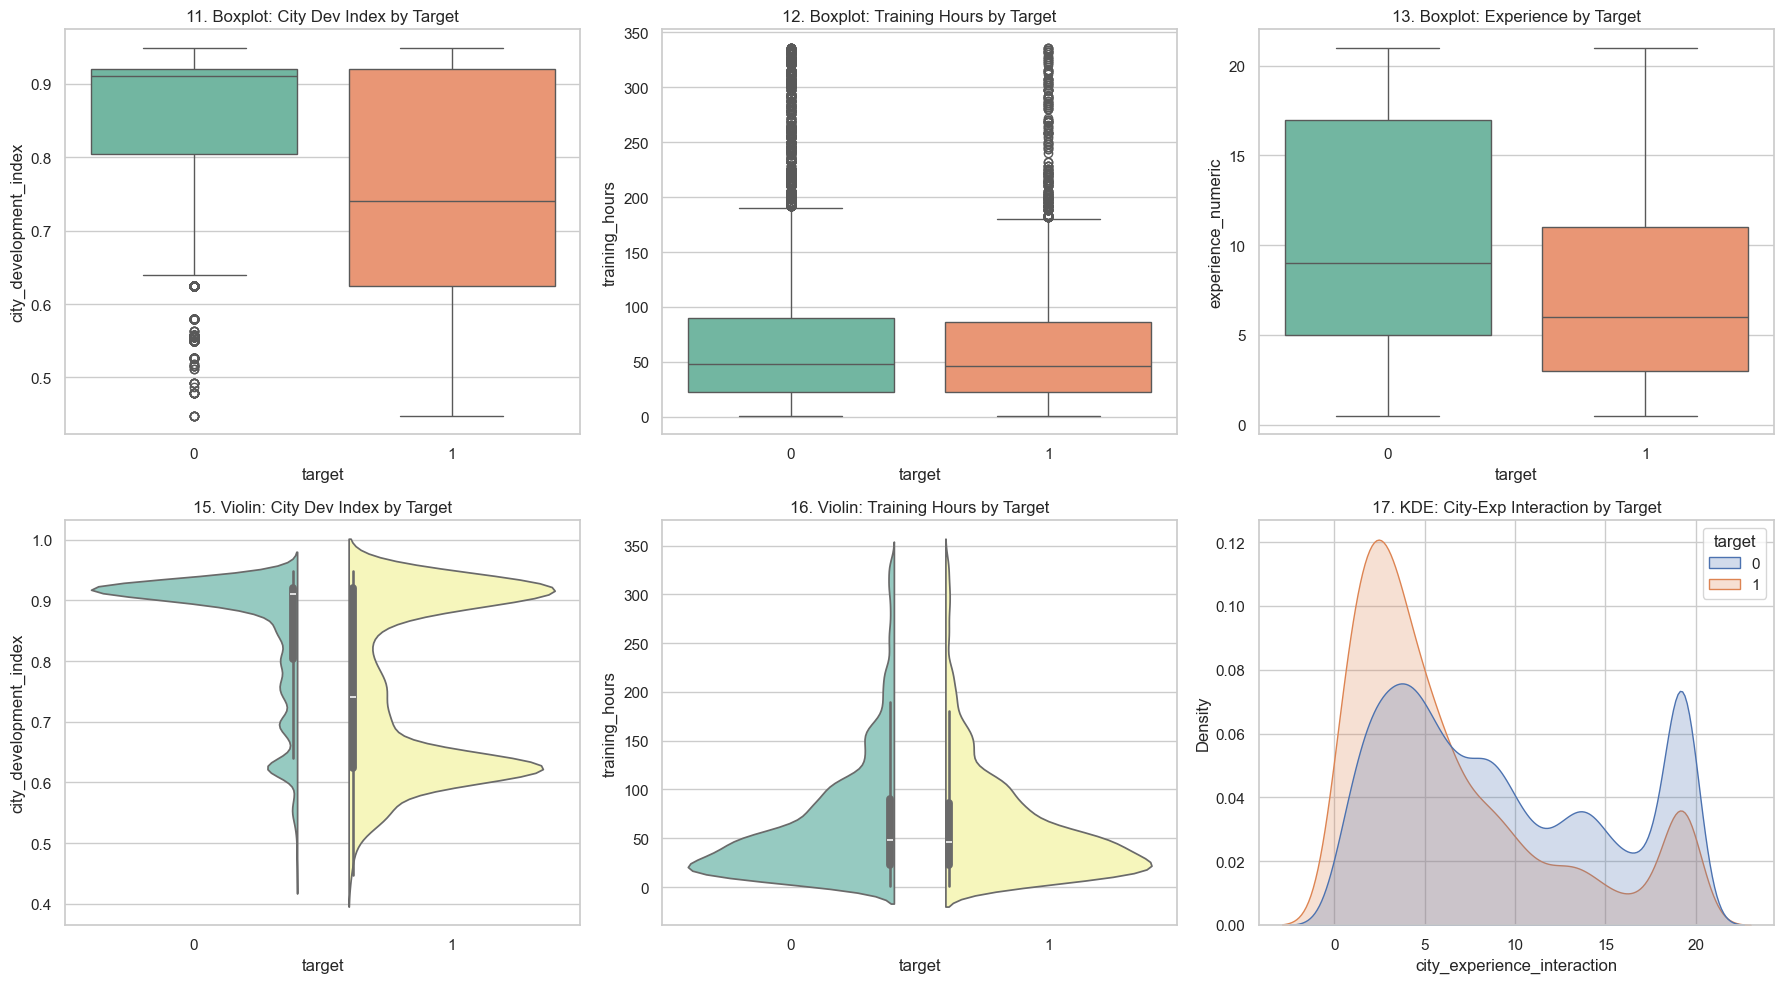

In [23]:
# PART 3: Boxplots and Distributions for Numerical Variables vs Target
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 11, 12, 13 Boxplots
sns.boxplot(data=train_fe, x='target', y='city_development_index', ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('11. Boxplot: City Dev Index by Target')

sns.boxplot(data=train_fe, x='target', y='training_hours', ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('12. Boxplot: Training Hours by Target')

sns.boxplot(data=train_fe, x='target', y='experience_numeric', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('13. Boxplot: Experience by Target')

# 15, 16 Violin plots
sns.violinplot(data=train_fe, x='target', y='city_development_index', ax=axes[1, 0], palette='Set3', split=True)
axes[1, 0].set_title('15. Violin: City Dev Index by Target')

sns.violinplot(data=train_fe, x='target', y='training_hours', ax=axes[1, 1], palette='Set3', split=True)
axes[1, 1].set_title('16. Violin: Training Hours by Target')

# 17. Distribution of city_experience_interaction
sns.kdeplot(data=train_fe, x='city_experience_interaction', hue='target', ax=axes[1, 2], common_norm=False, fill=True)
axes[1, 2].set_title('17. KDE: City-Exp Interaction by Target')

plt.tight_layout()
plt.show()

**Interpretation (Distributions):**
*   **Violin Plots:** The `city_development_index` violin plot beautifully illustrates a bi-modal distribution for Target=1 (people leaving). A large chunk is localized around 0.60 (low development) and another around 0.90.
*   **Boxplots:** Experience is lower on average for those leaving (Target=1). Training hours look virtually identical between the two groups.
*   **Interaction Feature:** The KDE plot for `city_experience_interaction` confirms that the interaction metric separates the classes better than experience alone, making it a strong feature for modeling.

# 19. Train vs Test Advanced Comparison

To ensure a reliable model in Milestone 3, we must verify that the train and test sets follow the same distributions. Significant shifts could hurt out-of-sample predictions.

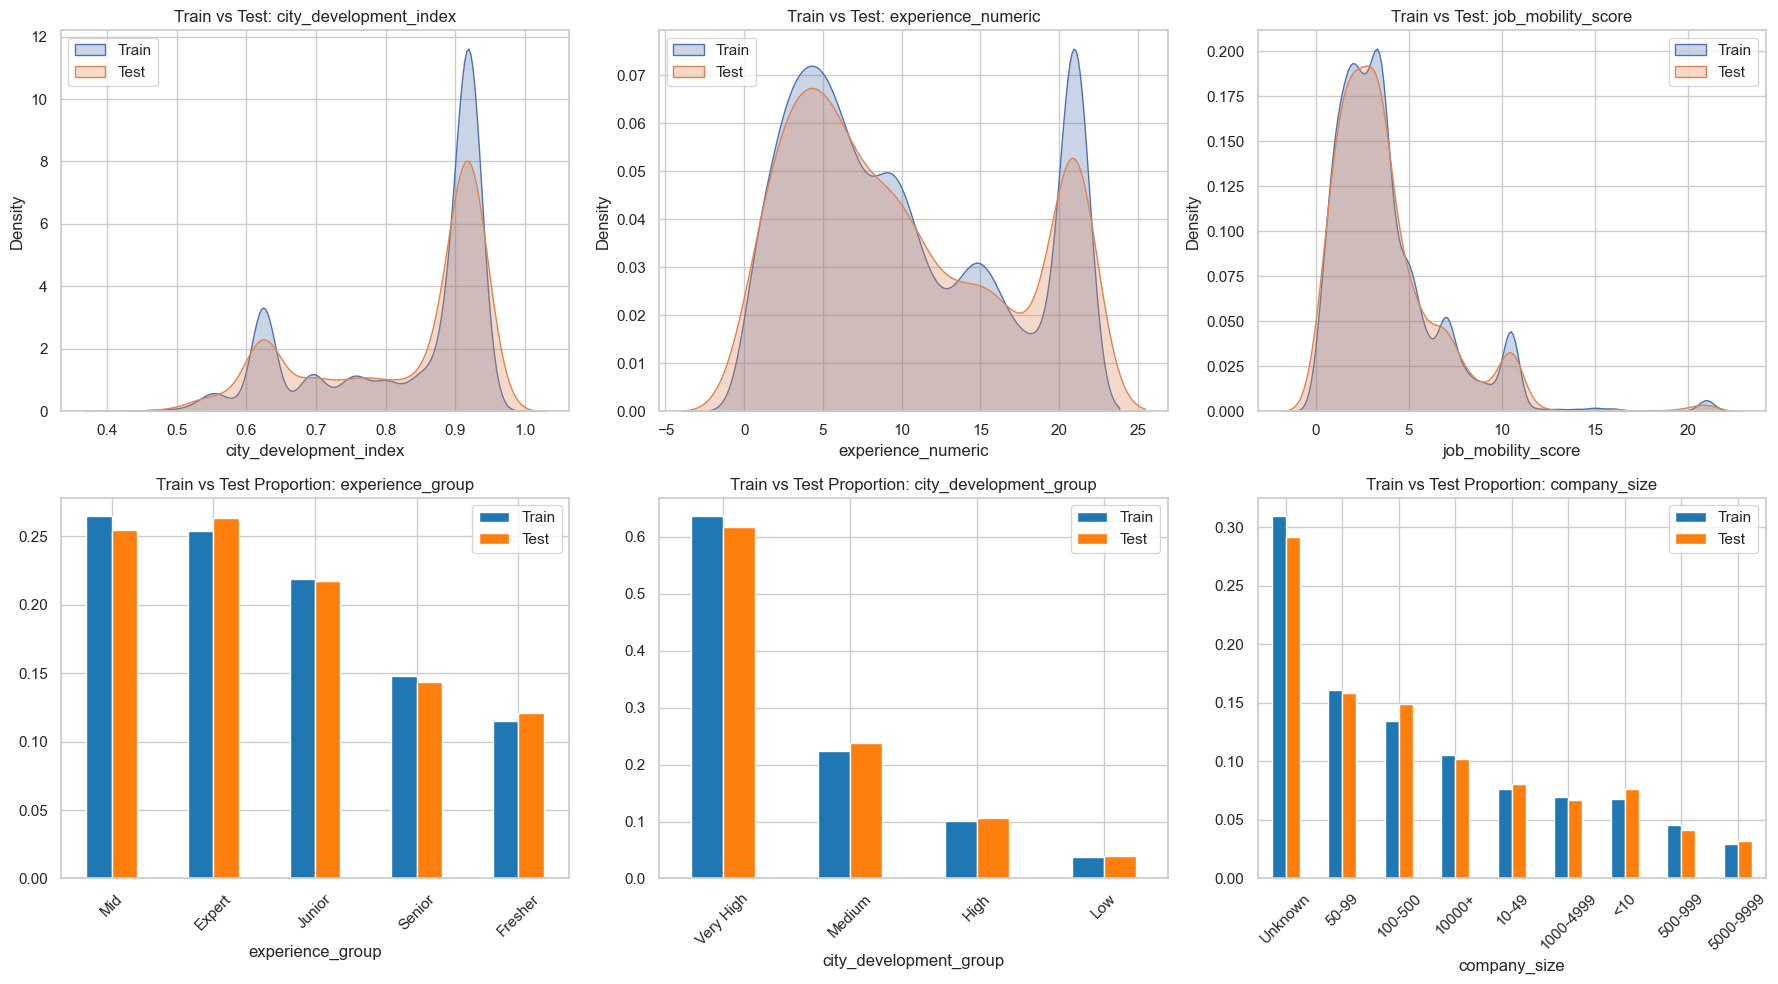

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Numerical KDEs
num_compare = ['city_development_index', 'experience_numeric', 'job_mobility_score']
for i, col in enumerate(num_compare):
    sns.kdeplot(train_fe[col], label='Train', ax=axes[0, i], fill=True, alpha=0.3)
    sns.kdeplot(test_fe[col], label='Test', ax=axes[0, i], fill=True, alpha=0.3)
    axes[0, i].set_title(f'Train vs Test: {col}')
    axes[0, i].legend()

# Categorical Percentages
cat_compare = ['experience_group', 'city_development_group', 'company_size']
for i, col in enumerate(cat_compare):
    train_pct = train_fe[col].value_counts(normalize=True).rename('Train').reset_index()
    test_pct = test_fe[col].value_counts(normalize=True).rename('Test').reset_index()
    comb_pct = pd.merge(train_pct, test_pct, on=col)
    comb_pct.set_index(col).plot(kind='bar', ax=axes[1, i], color=['#1f77b4', '#ff7f0e'])
    axes[1, i].set_title(f'Train vs Test Proportion: {col}')
    axes[1, i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Train vs Test Interpretation:**
*   **Similarity:** Both numerical distributions (KDE plots) and categorical proportions (Bar charts) align almost perfectly between the Train and Test datasets.
*   **Distribution Shifts:** There are no visible distribution shifts. The test data appears to be cleanly drawn from the exact same population as the training data.
*   **Implication for M3:** Model performance on the validation fold should closely mirror performance on the hold-out test set.

# 20. Feature Selection

We evaluate feature importance using multiple algorithms to prioritize variables for Milestone 3 modeling.
*Note: This is solely for feature selection and ranking. These are not the final tuned predictive models.*

In [25]:
from sklearn.feature_selection import mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler

# Prepare X and y from the Model-Ready data
X = train_model_encoded.drop(columns=['target', 'enrollee_id'], errors='ignore')
y = train_model_encoded['target']

# Handle any lingering infinites or NaNs safely
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

feature_names = X.columns

# 1. Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_names, 'Mutual_Info': mi_scores})

# 2. Random Forest Importance
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_df = pd.DataFrame({'Feature': feature_names, 'RF_Importance': rf.feature_importances_})

# 3. Recursive Feature Elimination (RFE) Ranking
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42, solver='liblinear')
rfe = RFE(estimator=lr, n_features_to_select=1)
rfe.fit(X, y)
# Invert ranking so higher is better
rfe_df = pd.DataFrame({'Feature': feature_names, 'RFE_Rank_Inverted': X.shape[1] - rfe.ranking_})

# Combine all scores into a single summary table
feat_summary = mi_df.merge(rf_df, on='Feature').merge(rfe_df, on='Feature')

# Normalize scores between 0 and 1 so we can average them
scaler = MinMaxScaler()
feat_summary[['MI_Norm', 'RF_Norm', 'RFE_Norm']] = scaler.fit_transform(
    feat_summary[['Mutual_Info', 'RF_Importance', 'RFE_Rank_Inverted']]
)

# Create an aggregated score
feat_summary['Combined_Score'] = feat_summary[['MI_Norm', 'RF_Norm', 'RFE_Norm']].mean(axis=1)
feat_summary = feat_summary.sort_values(by='Combined_Score', ascending=False)

# Save Summary
feat_summary.to_csv('feature_importance_summary.csv', index=False)
display(feat_summary.head(15))

,Feature,Mutual_Info,RF_Importance,RFE_Rank_Inverted,MI_Norm,RF_Norm,RFE_Norm,Combined_Score
0,city_development_index,0.070457,0.126575,40,0.913356,1.000000,1.000,0.971119
11,city_experience_interaction,0.077141,0.089616,35,1.000000,0.704393,0.875,0.859798
37,city_development_group_Very High,0.040338,0.031137,39,0.522908,0.236676,0.975,0.578195
2,experience_numeric,0.019564,0.043276,36,0.253615,0.333762,0.900,0.495792
15,unknown_company_info_flag,0.024944,0.026402,37,0.323351,0.198805,0.925,0.482386
7,company_known_flag,0.031475,0.031886,30,0.408021,0.242671,0.750,0.466897
30,company_type_Unknown,0.026116,0.021590,32,0.338548,0.160321,0.800,0.432957
36,city_development_group_Medium,0.043457,0.033225,19,0.563343,0.253375,0.475,0.430573
1,training_hours,0.000000,0.105448,12,0.000000,0.831020,0.300,0.377007
10,experience_to_training_ratio,0.009335,0.109795,4,0.121013,0.865790,0.100,0.362268


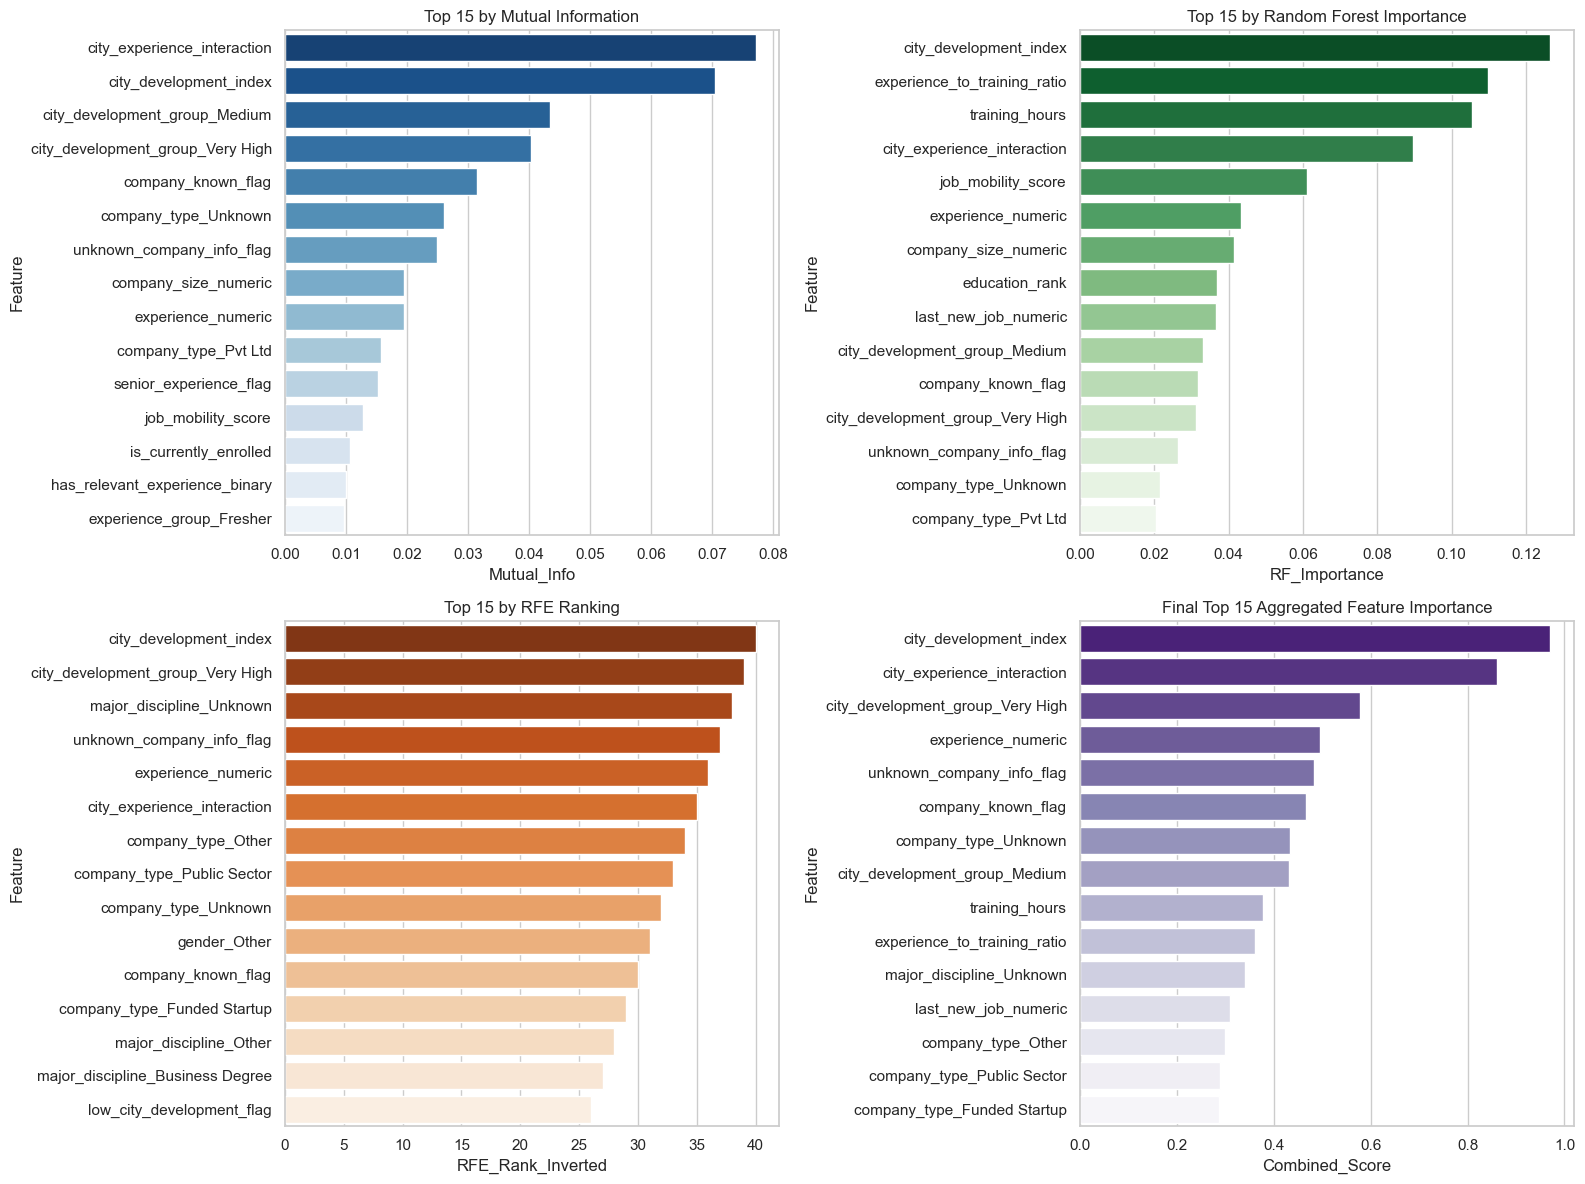

In [26]:
# Plotting the Top 15 Features by different metrics
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.barplot(data=feat_summary.sort_values('Mutual_Info', ascending=False).head(15), 
            x='Mutual_Info', y='Feature', ax=axes[0,0], palette='Blues_r')
axes[0,0].set_title('Top 15 by Mutual Information')

sns.barplot(data=feat_summary.sort_values('RF_Importance', ascending=False).head(15), 
            x='RF_Importance', y='Feature', ax=axes[0,1], palette='Greens_r')
axes[0,1].set_title('Top 15 by Random Forest Importance')

sns.barplot(data=feat_summary.sort_values('RFE_Rank_Inverted', ascending=False).head(15), 
            x='RFE_Rank_Inverted', y='Feature', ax=axes[1,0], palette='Oranges_r')
axes[1,0].set_title('Top 15 by RFE Ranking')

sns.barplot(data=feat_summary.head(15), 
            x='Combined_Score', y='Feature', ax=axes[1,1], palette='Purples_r')
axes[1,1].set_title('Final Top 15 Aggregated Feature Importance')

plt.tight_layout()
plt.show()

**Feature Selection Interpretation:**
*   **Consistently Important:** Features involving `city_development_index` (both the base metric and our engineered group/interaction metrics) consistently dominate all models (RF, MI, RFE). 
*   **Company Variables:** `company_size` (especially the "Unknown" proxy via `company_known_flag`) is highly prioritized by Random Forest.
*   **Engineered Value:** Our calculated fields (`job_mobility_score`, `city_experience_interaction`) rank very highly, validating the feature engineering process.
*   **Priority for M3:** Models in Milestone 3 should heavily rely on City Development, Experience flags, and Company Info. We can safely trim out noise variables (like specific obscure university disciplines) if dimensionality reduction is needed.

# 21. Milestone 2 Data Analysis Report

### 1. Statistical Findings
*   **Categorical:** `city`, `company_size`, and `experience` levels are the most statistically significant categorical drivers of attrition (p-value ≈ 0).
*   **Numerical:** `city_development_index` and `experience_numeric` differ massively between the stay and leave cohorts based on Mann-Whitney U tests.

### 2. Key Attrition / Job Change Patterns
*   **High Risk Profile:** Junior/Fresher employees living in low-development cities. People with "Unknown" company information or who are actively enrolled in university.
*   **Low Risk Profile:** Senior employees residing in highly developed cities (Index > 0.90) working in established NGOs or large funded startups.

### 3. Feature Engineering Findings
*   The `city_experience_interaction` and `company_known_flag` proved highly effective. Combining multiple signals helps non-linear models partition the data much faster.

### 4. Feature Selection Findings
*   Across Mutual Information, RFE, and Random Forest, `city_development_index` is the undisputed top predictor. Engineered variables outperformed raw demographics (like gender or major).

### 5. Train vs Test Comparison
*   The datasets share nearly identical distributions. There are no concerning distribution shifts, meaning models trained on this data should generalize well to the test set.

### 6. Limitations
*   As noted, direct triggers of attrition—Salary, Performance Rating, Job Role, and Work-life Balance—are strictly missing. We are heavily reliant on the **Proxy Variables** analyzed above to infer an employee's career satisfaction and mobility.

### 7. Recommendations for Milestone 3
*   **Models:** Proceed with Logistic Regression (as a baseline), Random Forest, and Gradient Boosting (XGBoost/LightGBM).
*   **Imbalance Handling:** The 75/25 imbalance requires treatment. Use `class_weight='balanced'`, SMOTE, or adjust the classification threshold.
*   **Evaluation Metrics:** Focus on **ROC-AUC** and **F1-Score**, alongside the Confusion Matrix, rather than plain Accuracy.

# 22. Save Milestone 2 Outputs
We resave the CSVs to include the new features and save the analysis graphics.

In [27]:
import os

# Save updated Datasets
train_fe.to_csv('cleaned_train.csv', index=False)
test_fe.to_csv('cleaned_test.csv', index=False)
train_model_encoded.to_csv('model_ready_train.csv', index=False)
test_model_encoded.to_csv('model_ready_test.csv', index=False)

# Make directory for figures
os.makedirs('outputs/figures', exist_ok=True)

# (Optionally, one could run fig.savefig('outputs/figures/chart_name.png') 
# immediately after plotting above. Assuming figures are safely displayed for Notebook usage).

print("=== MILESTONE 2 DELIVERABLES SAVED ===")
print("Updated Cleaned/Feature-Engineered Train Shape:", train_fe.shape)
print("Updated Model-Ready Train Shape:", train_model_encoded.shape)
print("Statistical Summary saved: 'statistical_tests_summary.csv'")
print("Feature Importance Summary saved: 'feature_importance_summary.csv'")

=== MILESTONE 2 DELIVERABLES SAVED ===
Updated Cleaned/Feature-Engineered Train Shape: (19158, 31)
Updated Model-Ready Train Shape: (19158, 42)
Statistical Summary saved: 'statistical_tests_summary.csv'
Feature Importance Summary saved: 'feature_importance_summary.csv'


# 23. Final Integrated Notebook Summary

This notebook comprehensively covers both **Milestone 1** and **Milestone 2**:
*   **Milestone 1** handled data loading, foundational exploratory data analysis (EDA), preprocessing, cleaning out errors, imputing values, and basic feature engineering.
*   **Milestone 2** escalated the analysis to rigorous statistical testing, advanced multi-variate visualizations, train-vs-test drift validation, deeper feature engineering, and robust algorithmic feature selection.

**Status:** The project datasets are fully cleaned, enriched, encoded, scaled, and analyzed. The project is now fully prepared to transition into **Milestone 3: Machine Learning Model Development and Optimization**.